# Equilibrium SYK and antisymmetric engineered-kernel analysis

This notebook keeps the original equilibrium analysis and replaces the engineered-kernel Schwarzian fit by the central odd-in-$\lambda$ response
$\frac{G_{+\lambda}(0,t)-G_{-\lambda}(0,t)}{2|\lambda|\,G_c(0,t)}.$
The convention used below is $G(0,t)=G_{\rm eq}(-t)$ for $t>0$.


In [4]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import mpmath as mp


## Choices

In [5]:
root = Path("/Users/meabh/Desktop/CC Quench States/SYK Quenches/syk_sims").expanduser()
eq_root = root / "eq_runs"
J4_keep = 1.0

# Equilibrium plots
beta_keep_eq = [12, 15, 18, 20, 24,25, 30]

# Engineered-kernel plots
beta_keep_kernel = [ 24, 30, 36, 40, 42, 48, 50]
lambda_keep = [0.005]

# (delta, Lambda) pairs
delta_cutoff_keep = [
    #(-0.020537, 0.4),
    #(-0.021,    0.4),
    #(-0.03,     0.5),
    (-0.043936, 0.65),
    #(-0.044,    0.65),
    (-0.053648, 0.75),
   #(-0.054,    0.75),
]
delta_keep, cutoff_keep = zip(*delta_cutoff_keep)

# UV timescale below which short-time transients (~Jt for ordinary
# equilibrium, ~t/Lambda for the engineered kernel) dominate over the
# t/beta conformal scaling
T_PLOT_MIN_EQ_COEFF = 0.1 #2.0
T_PLOT_MIN_KERNEL_COEFF = 16.0

# Fit-window lower bound: "absolute" reuses same physical UV cut
# ; "relative" fixes x_fit_min = 1/(2*pi) regardless of J/Lambda.
FIT_WINDOW_MODE = "absolute"
X_FIT_MIN_RELATIVE = 1 / (2 * np.pi)

x_plot_max = 5.0
h0_fit_x_max = 5.0

Delta = 1 / 4
alpha0_original = 0.2648
alpha1 = 0.32679563
a00 = 9.0 / 4.0 

## Load all equilibrium files

In [6]:
def decode_number(value):
    s = str(value)
    s = s.replace("em", "e-").replace("ep", "e+")
    if s.startswith("m"):
        s = "-" + s[1:]
    return float(s.replace("p", "."))


def folder_value(folder, tag, default=np.nan):
    match = re.search(rf"(?:^|_){re.escape(tag)}_([^_]+)", folder)
    return decode_number(match.group(1)) if match else default


rows = []

for filename in sorted(eq_root.glob("**/*.npz")):
    try:
        with np.load(filename, allow_pickle=True) as data:
            if not {"tau_grid", "Ggt_tau"}.issubset(data.files):
                continue

            if "metadata_json" in data.files:
                raw = np.asarray(data["metadata_json"]).item()
                if isinstance(raw, bytes):
                    raw = raw.decode()
                meta = json.loads(str(raw))
            else:
                meta = {}

        folder = filename.parent.name

        lam = meta.get("kernel_lambda", folder_value(folder, "lam"))
        delta_value = meta.get("kernel_c", folder_value(folder, "c"))
        cutoff = meta.get("kernel_cutoff", folder_value(folder, "L"))

        is_kernel = (
            "_lam_" in folder
            or np.isfinite(float(lam))
            or np.isfinite(float(delta_value))
            or np.isfinite(float(cutoff))
        )

        rows.append({
            "filename": str(filename),
            "folder": folder,
            "is_kernel": is_kernel,
            "J2": float(meta.get("J2", 0.0)),
            "J4": float(meta.get("J4", folder_value(folder, "J4"))),
            "beta": float(meta.get("beta", folder_value(folder, "b"))),
            "mu": float(meta.get("mu", meta.get("chemical_potential", folder_value(folder, "mu", 0.0)))),
            "kernel_lambda": float(lam) if np.isfinite(float(lam)) else 0.0,
            "kernel_delta": float(delta_value) if np.isfinite(float(delta_value)) else 0.0,
            "kernel_cutoff": float(cutoff) if np.isfinite(float(cutoff)) else np.nan,
            "dt": float(meta.get("dt", folder_value(folder, "dt"))),
            "omega_max": float(meta.get("omega_max", folder_value(folder, "om"))),
            "Nw": int(meta.get("Nw", folder_value(folder, "Nw", -1))),
            "tol": float(meta.get("tol", np.nan)),
        })

    except Exception as exc:
        print(f"Skipping {filename}: {exc}")


df_all_eq = pd.DataFrame(rows)

df_eq_all = (
    df_all_eq[~df_all_eq["is_kernel"]]
    .sort_values(["J4", "beta", "mu", "dt", "Nw", "omega_max"])
    .reset_index(drop=True)
)

df_kernel_all = (
    df_all_eq[df_all_eq["is_kernel"]]
    .sort_values([
        "J4", "beta", "mu", "kernel_lambda", "kernel_delta",
        "kernel_cutoff", "dt", "Nw", "omega_max"
    ])
    .reset_index(drop=True)
)

print("Original equilibrium files:", len(df_eq_all))
print("Engineered-kernel files:", len(df_kernel_all))

Skipping /Users/meabh/Desktop/CC Quench States/SYK Quenches/syk_sims/eq_runs/eq_J4_1_b_12_lam_m0p005_c_0p72_L_4p0_dt_0p0016_om_36_Nw_8641 (1)/syk_eq_J2_0_J4_1_beta_12_klam_m0p005_kc_0p72_kcut_4_dt_0p0016_om_36_Nw_8641_tol_1em08_c52a082f.npz: could not convert string to float: '8641 (1)'
Skipping /Users/meabh/Desktop/CC Quench States/SYK Quenches/syk_sims/eq_runs/eq_J4_1_b_12_lam_m0p005_c_0p72_L_4p0_dt_0p0016_om_36_Nw_8641 (2)/syk_eq_J2_0_J4_1_beta_12_klam_m0p005_kc_0p72_kcut_4_dt_0p0016_om_36_Nw_8641_tol_1em08_c52a082f.npz: could not convert string to float: '8641 (2)'
Skipping /Users/meabh/Desktop/CC Quench States/SYK Quenches/syk_sims/eq_runs/eq_J4_1_b_12_lam_m0p005_c_0p72_L_4p0_dt_0p0016_om_36_Nw_8641 (3)/syk_eq_J2_0_J4_1_beta_12_klam_m0p005_kc_0p72_kcut_4_dt_0p0016_om_36_Nw_8641_tol_1em08_c52a082f.npz: could not convert string to float: '8641 (3)'
Skipping /Users/meabh/Desktop/CC Quench States/SYK Quenches/syk_sims/eq_runs/eq_J4_1_b_12_lam_m0p005_c_0p72_L_4p0_dt_0p0016_om_36_Nw_864

## Keep the best numerical resolution for each physical parameter set

In [7]:
# Ranking requested here:
#     smallest tol, smallest dt, then largest Nw, then largest omega_max.

eq_keys = ["J2", "J4", "beta", "mu"]
kernel_keys = [
    "J2", "J4", "beta", "mu",
    "kernel_lambda", "kernel_delta", "kernel_cutoff",
]

df_eq_best = (
    df_eq_all
    .sort_values(
        eq_keys + ["tol","dt", "Nw", "omega_max"],
        ascending=[True] * len(eq_keys) + [True, True, False, False],
    )
    .drop_duplicates(eq_keys, keep="first")
    .reset_index(drop=True)
)

df_kernel_best = (
    df_kernel_all
    .sort_values(
        kernel_keys + ["tol","dt", "Nw", "omega_max"],
        ascending=[True] * len(kernel_keys) + [True, True, False, False],
    )
    .drop_duplicates(kernel_keys, keep="first")
    .reset_index(drop=True)
)


def selected(values, keep):
    if keep is None:
        return np.ones(len(values), dtype=bool)
    return np.any(
        np.isclose(
            np.asarray(values, dtype=float)[:, None],
            np.asarray(keep, dtype=float)[None, :],
        ),
        axis=1,
    )


def selected_pairs(values_a, values_b, keep_a, keep_b):
    # Like selected(), but keep_a/keep_b are matched pairwise by index
    # (keep_a[i], keep_b[i]), not as an independent cartesian product --
    # e.g. delta_keep/cutoff_keep are meant as (delta, Lambda) pairs.
    if keep_a is None or keep_b is None:
        return np.ones(len(values_a), dtype=bool)
    values_a = np.asarray(values_a, dtype=float)
    values_b = np.asarray(values_b, dtype=float)
    mask = np.zeros(len(values_a), dtype=bool)
    for a, b in zip(keep_a, keep_b):
        mask |= np.isclose(values_a, a) & np.isclose(values_b, b)
    return mask


eq_mask = (
    np.isclose(df_eq_best["J4"], J4_keep)
    & np.isclose(df_eq_best["mu"], 0.0)
    & selected(df_eq_best["beta"], beta_keep_eq)
)

kernel_mask = (
    np.isclose(df_kernel_best["J4"], J4_keep)
    & np.isclose(df_kernel_best["mu"], 0.0)
    & selected(df_kernel_best["beta"], beta_keep_kernel)
    & selected(np.abs(df_kernel_best["kernel_lambda"]), lambda_keep)
    & selected_pairs(
        df_kernel_best["kernel_delta"], df_kernel_best["kernel_cutoff"],
        delta_keep, cutoff_keep,
    )
)

df_eq_plot = df_eq_best[eq_mask].copy()
df_kernel_plot = df_kernel_best[kernel_mask].copy()

## Small trace and theory helpers

In [8]:
def load_G0t(filename):
    with np.load(filename, allow_pickle=True) as data:
        tau = np.asarray(data["tau_grid"], dtype=float).squeeze()
        G = np.asarray(data["Ggt_tau"], dtype=complex).squeeze()

    keep = tau < 0
    t = -tau[keep]
    G = G[keep]

    order = np.argsort(t)
    return t[order], G[order]


def Gc_im_abs(t, beta, J):
    b = (1 / (4 * np.pi * J**2)) ** 0.25
    return (
        b
        * np.cos(np.pi / 4)
        * (np.pi / (beta * np.sinh(np.pi * t / beta))) ** 0.5
    )



def Gc_complex(t, beta, J):
    amplitude = (
        (0.5 - Delta)
        * np.tan(np.pi * Delta)
        / (np.pi * J**2)
    ) ** Delta

    envelope = amplitude * (
        np.pi / (beta * np.sinh(np.pi * t / beta))
    ) ** (2 * Delta)

    # G_c^>(-t), matching G(0,t)=G_eq(-t).
    return envelope * (
        np.sin(np.pi * Delta)
        - 1j * np.cos(np.pi * Delta)
    )


def f_h0(x):
    # Here tanh^{-1} means coth = 1/tanh, matching the existing notebook.
    return (2 * np.pi * x + np.pi) / np.tanh(np.pi * x) - 2


def uv_t_plot_min(*, J=None, Lambda=None):
    # Ordinary equilibrium: pass J. Engineered kernel: pass Lambda.
    if Lambda is not None:
        return T_PLOT_MIN_KERNEL_COEFF / Lambda
    return T_PLOT_MIN_EQ_COEFF / J


def fit_x_min_for(x_plot_min_row):
    if FIT_WINDOW_MODE == "absolute":
        return x_plot_min_row
    if FIT_WINDOW_MODE == "relative":
        return X_FIT_MIN_RELATIVE
    raise ValueError(f"Unknown FIT_WINDOW_MODE: {FIT_WINDOW_MODE!r}")


# One colour family per Lambda; beta sets the shade within it 
_LAMBDA_CMAP_ZERO = "Greys"
_LAMBDA_CMAPS = ["Blues", "Oranges", "Greens", "Reds", "Purples"]


def _colour_for(Lambda, beta, lambdas, betas):
    nonzero = [L for L in lambdas if not np.isclose(L, 0.0)]
    if np.isclose(Lambda, 0.0):
        cmap = plt.colormaps[_LAMBDA_CMAP_ZERO]
    else:
        cmap = plt.colormaps[_LAMBDA_CMAPS[nonzero.index(Lambda) % len(_LAMBDA_CMAPS)]]
    beta_pos = betas.index(beta) / max(len(betas) - 1, 1)
    return cmap(0.35 + 0.55 * beta_pos)

### Real-time $h_1$ template

`f_h0` above is the real-time continuation of the closed-form $f_0(u)=2+\pi(1-2u)\cot(\pi u)$
under $\tau\to-it$ (i.e. $u\to-ix$, $x=t/\beta$), combined as $\mathrm{Im}-\mathrm{Re}$:
$f_0(x)=\mathrm{Im}\,f_0(-ix)-\mathrm{Re}\,f_0(-ix)$. This is verified below to reproduce the
closed-form `f_h0` to machine precision. The same recipe applied to the general conformal block
$f_h(u)$ (Eq. (20) of Arguello Cruz & Tarnopolsky, Phys. Rev. B **108**, 035103 (2023)) at
$h=h_1\approx3.7735$ gives the real-time $h_1$ template $f_1(x)$, used below to fit

$$
(\beta J)\,D_\lambda(x) = b_0\,f_0(x) + b_1\,\frac{f_1(x)}{(\beta J)^{h_1-2}},
$$

the real-time analogue of the Euclidean expansion
$G_*/G_c-1=-\alpha_0/(\beta J)f_0-\alpha_1/(\beta J)^{h_1-1}f_1-\cdots$ (Eq. (22) of the same paper).
With this normalization $b_0,b_1$ are directly comparable to $\alpha_0,\alpha_1$. The $f_{00}$ term
is dropped: its coefficient scales as $\alpha_0^2$, so whenever $b_0$ is tuned toward zero it is
doubly suppressed relative to the $h_1$ term kept here.


In [9]:
mp.mp.dps = 30
_DELTA_CFT = mp.mpf(1) / 4

def _k_of_h(h):
    return (
        mp.gamma(2 * _DELTA_CFT - h) * mp.gamma(h + 2 * _DELTA_CFT - 1)
        / (mp.gamma(2 * _DELTA_CFT - 2) * mp.gamma(2 * _DELTA_CFT + 1))
    ) * (1 - mp.sin(mp.pi * h) / mp.sin(2 * mp.pi * _DELTA_CFT))


H1 = float(mp.findroot(lambda h: _k_of_h(h) - 1, mp.mpf("3.77")))


def _general_f_h_complex(u, h):
    # Eq. (20) of Arguello Cruz & Tarnopolsky (2023), evaluated at complex u.
    theta = 2 * mp.pi * u
    z = mp.e ** (1j * theta)

    def A(zz):
        return (1 - zz) ** h * mp.hyp2f1(h, h, 1, zz)

    numerator = A(z) + A(mp.conj(z))
    value = (
        (2 * mp.pi) ** (h - 1) * mp.gamma(h) ** 2 * numerator
        / (2 * mp.sin(mp.pi * h / 2) * mp.gamma(2 * h - 1))
    )
    return complex(value)


_f_x_grid = np.linspace(0.02, 8.0, 800)
_f_h1_table = np.array(
    [_general_f_h_complex(-1j * xx, H1) for xx in _f_x_grid]
)
_f_h1_table = _f_h1_table.imag - _f_h1_table.real


def f_h1(x):
    return np.interp(np.asarray(x, dtype=float), _f_x_grid, _f_h1_table)


def f_h1_scaled(x, betaJ):
    return f_h1(x) / betaJ ** (H1 - 2.0)

def f_00(x):
    # Analytic continuation (u -> -ix, same Im-Re recipe as f_h0/f_h1 above) of
    # the fitted Euclidean f00(tau+it) ~= A + B*cot^2(pi (tau+it)) + C*(1-2|tau+it|)^2 approximation
    # (A=4.937, B=9.076, C=2.322). Every term needs the substitution applied
    # consistently -- (1-2u)^2 -> (1+2ix)^2 -> contributes 4Cx^2+4Cx once Im-Re'd,
    # not (1-2x)^2 evaluated at real x.
    x = np.asarray(x, dtype=float)
    A, B, C = 4.937, 9.076, 2.322
    coth = 1.0 / np.tanh(np.pi * x)
    return B * coth**2 + 4 * C * x**2 - 4 * C * x - (A + C)

def f_00_v2(x):
    # Same Im-Re(-ix) continuation as f_00, but using A,B,C refit directly against
    # f00_apparent(u; betaJ=30), u>=0.15 (0.72% RMS) instead of the converged large-betaJ
    # f00(u) table -- A=5.4944, B=9.6247, C=6.6013.
    x = np.asarray(x, dtype=float)
    A2, B2, C2 = 5.4944, 9.6247, 6.6013
    coth = 1.0 / np.tanh(np.pi * x)
    return B2 * coth**2 + 4 * C2 * x**2 - 4 * C2 * x - (A2 + C2)

# Sanity check of Im-Re(-ix) against closed form (h=2 exactly)
_xcheck = np.linspace(0.1, 4.0, 25)
_ucheck = -1j * _xcheck
_f0check = 2 + np.pi * (1 - 2 * _ucheck) / np.tan(np.pi * _ucheck)
_f0check = _f0check.imag - _f0check.real

print(f"h1 = {H1:.10f}  (paper quotes ~3.7735)")
print(
    "f_h0 cross-check, max|Im-Re(-ix) recipe - closed form| =",
    np.max(np.abs(_f0check - f_h0(_xcheck))),
)


h1 = 3.7735356186  (paper quotes ~3.7735)
f_h0 cross-check, max|Im-Re(-ix) recipe - closed form| = 1.0658141036401503e-14


## 1. Original equilibrium data: $|\mathrm{Im}\,G(0,t)|$

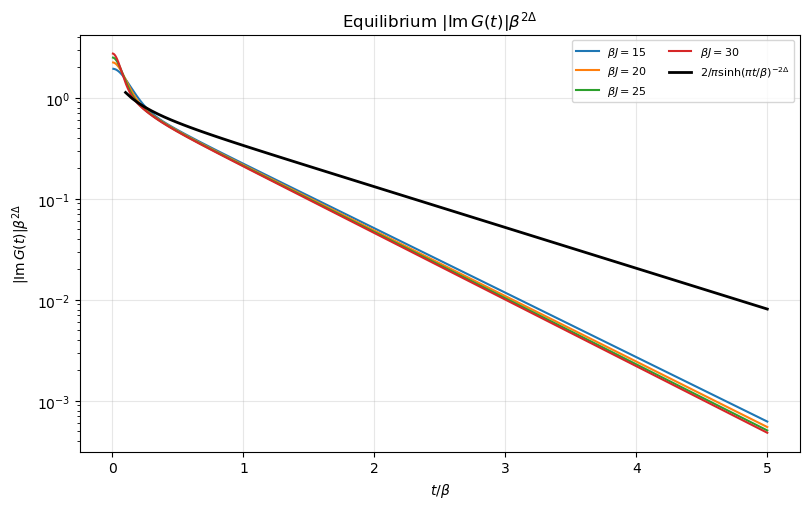

In [10]:
fig, ax = plt.subplots(figsize=(8.2, 5.2))

for _, row in df_eq_plot.sort_values("beta").iterrows():
    t, G = load_G0t(row["filename"])
    beta = float(row["beta"])
    J = float(row["J4"])
    x_min_row = uv_t_plot_min(J=J) / beta

    keep = (
        (t > 0)
        & (t / beta >= x_min_row)
        & (t / beta <= x_plot_max)
    )

    ax.plot(
        t[keep] / beta,
        np.abs(np.imag(G[keep]))*beta**0.5,
        lw=1.5,
        label=rf"$\beta J={beta * row['J4']:g}$",
    )

ax.plot(
    np.linspace(0.1,5,100),
    2/np.pi*(np.sinh(np.pi*np.linspace(0.1,3,100)))**(-1/2),
    color="black",
    lw=2,
    label=(r"$2/\pi \sinh(\pi t/\beta)^{-2\Delta}$"),
)

ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(r"$|\operatorname{Im}G(t)|\beta^{2\Delta}$")
ax.set_title(r"Equilibrium $|\operatorname{Im}G(t)|\beta^{2\Delta}$")
ax.grid(alpha=0.3)
ax.set_yscale('log')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

### Original equilibrium correction and the $h=2$ template

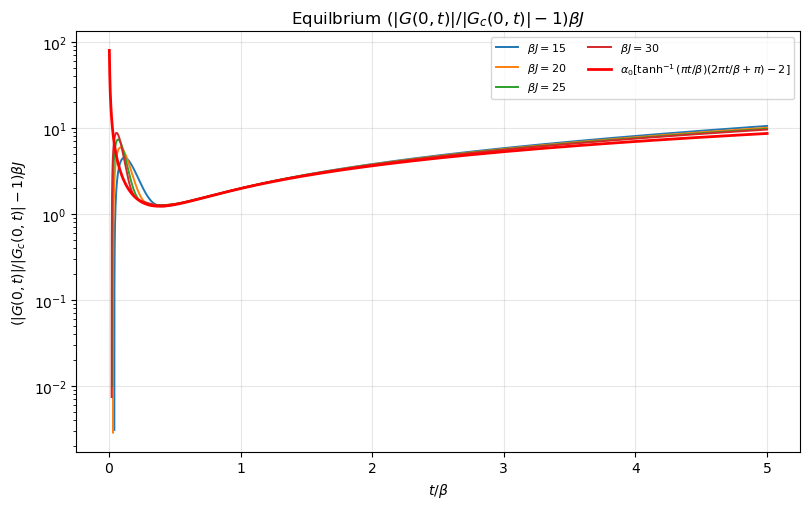

In [11]:
fig, ax = plt.subplots(figsize=(8.2, 5.2))

x_theory_min = uv_t_plot_min(J=J4_keep) / df_eq_plot["beta"].max()

for _, row in df_eq_plot.sort_values("beta").iterrows():
    J = float(row["J4"])
    beta = float(row["beta"])
    t, G = load_G0t(row["filename"])

    x = t / beta
    x_min_row = uv_t_plot_min(J=J) / beta
    ratio = np.abs(np.imag(G)) / Gc_im_abs(t, beta, J)
    correction = (ratio - 1) * beta * J

    keep = (
        np.isfinite(correction)
        & (correction > 0)
        & (x >= x_min_row)
        & (x <= x_plot_max)
    )

    ax.plot(
        x[keep],
        correction[keep],
        lw=1.4,
        label=rf"$\beta J={beta * J:g}$",
    )

x_theory = np.logspace(
    np.log10(x_theory_min),
    np.log10(x_plot_max),
    500,
)

ax.plot(
    x_theory,
    alpha0_original * f_h0(x_theory),
    color="red",
    lw=2,
    label=(
        r"$\alpha_0[\tanh^{-1}(\pi t/\beta)"
        r"(2\pi t/\beta+\pi)-2]$"
    ),
)

#ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(r"$(|G(0,t)|/|G_c(0,t)|-1)\beta J$")
ax.set_title(r"Equilbrium $(|G(0,t)|/|G_c(0,t)|-1)\beta J$")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

### Fit the ordinary-equilibrium $h=2$ amplitude

In [12]:
ordinary_h0_rows = []

for _, row in df_eq_plot.sort_values("beta").iterrows():
    J = float(row["J4"])
    beta = float(row["beta"])
    t, G = load_G0t(row["filename"])

    x = t / beta
    correction = (
        np.abs(np.imag(G)) / Gc_im_abs(t, beta, J) - 1
    ) * beta * J

    x_min_row = uv_t_plot_min(J=J) / beta
    fit_lo = fit_x_min_for(x_min_row)

    fit = (
        np.isfinite(correction)
        & (x >= fit_lo)
        & (x <= h0_fit_x_max)
    )

    f = f_h0(x[fit])
    amplitude = np.dot(f, correction[fit]) / np.dot(f, f)

    ordinary_h0_rows.append({
        "beta": beta,
        "betaJ": beta * J,
        "mu": float(row["mu"]),
        "h0_amplitude": amplitude,
        "filename": row["filename"],
    })

df_h0_ordinary = pd.DataFrame(ordinary_h0_rows)
display(df_h0_ordinary)

,beta,betaJ,mu,h0_amplitude,filename
0,15.0,15.0,0.0,0.278775,/Users/meabh/Desktop/CC Quench States/SYK Quen...
1,20.0,20.0,0.0,0.262992,/Users/meabh/Desktop/CC Quench States/SYK Quen...
2,25.0,25.0,0.0,0.251269,/Users/meabh/Desktop/CC Quench States/SYK Quen...
3,30.0,30.0,0.0,0.241715,/Users/meabh/Desktop/CC Quench States/SYK Quen...


### Plot after subtracting the leading $h=2$ contribution

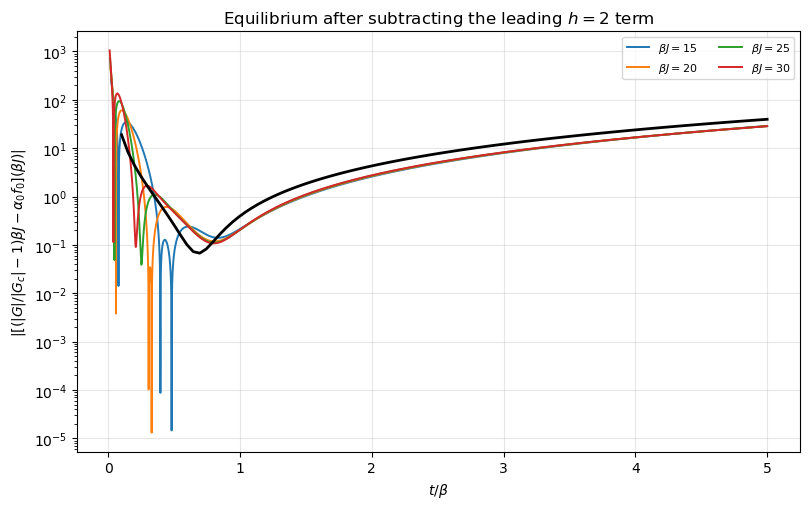

In [13]:
fig, ax = plt.subplots(figsize=(8.2, 5.2))

for _, row in df_eq_plot.sort_values("beta").iterrows():
    J = float(row["J4"])
    beta = float(row["beta"])
    t, G = load_G0t(row["filename"])

    x = t / beta
    x_min_row = 3*uv_t_plot_min(J=J) / beta
    ratio = np.abs(np.imag(G)) / Gc_im_abs(t, beta, J)

    leading = alpha0_original * f_h0(x)
    residual = ((ratio - 1) * beta * J - leading) * beta * J

    keep = (
        np.isfinite(residual)
        & (np.abs(residual) > 0)
        & (x >= x_min_row)
        & (x <= x_plot_max)
    )

    ax.plot(
        x[keep],
        np.abs(residual[keep]),
        lw=1.4,
        label=rf"$\beta J={beta * J:g}$",
    )

ax.plot(
    np.linspace(0.1,5,100),
    a00 * alpha0_original**2 * f_00(np.linspace(0.1,5,100))/0.75,
    color="black",
    lw=2,
    #label=(r"$a_{00}\alpha_{00}^2[\tanh^{-1}(\pi t/\beta)"r"(2\pi t/\beta+\pi)-2]$"),
)
#ax.plot(np.linspace(0.1,3,100),a00 * alpha0_original**2 * f_00_v2(np.linspace(0.1,3,100)),color="purple",lw=2,ls="--",
    #label=r"$a_{00}\alpha_0^2\,f_{00}^{v2}(x)$ ($\beta J{=}30$-refit $A,B,C$)",
#)
#ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(
    r"$|[(|G|/|G_c|-1)\beta J-\alpha_0 f_0](\beta J)|$"
)
ax.set_title(r"Equilibrium after subtracting the leading $h=2$ term")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

### Same plot, but with $b_0,b_{00}$ fit numerically (not fixed to $\alpha_0$, $a_{00}\alpha_0^2$)

Separate from the plot above (which subtracts the *fixed*, $\beta J\to\infty$ asymptotic
$\alpha_0=0.2648$ before comparing against the theoretical $a_{00}\alpha_0^2\,f_{00}(x)$
curve). Here $b_0,b_{00}$ are instead fit jointly, per $\beta$, by linear least squares against
$(|G|/|G_c|-1)\beta J = b_0\,f_{h_0}(x) + [b_{00}/\beta J]\,f_{00}(x)$ directly -- no
externally-fixed leading amplitude, so no contamination from the leading term being ~5-7% off at
these finite $\beta J$ (cell 19's own $h_0$-amplitude fits already show this: 0.284, 0.281, 0.279,
0.278 vs. the asymptotic 0.2648).

,betaJ,b0,b00,b00_over_theory
0,15.0,0.337699,-0.136370,-0.864369
1,20.0,0.322643,-0.148262,-0.939751
2,25.0,0.312046,-0.149904,-0.950158
3,30.0,0.304738,-0.149213,-0.945773


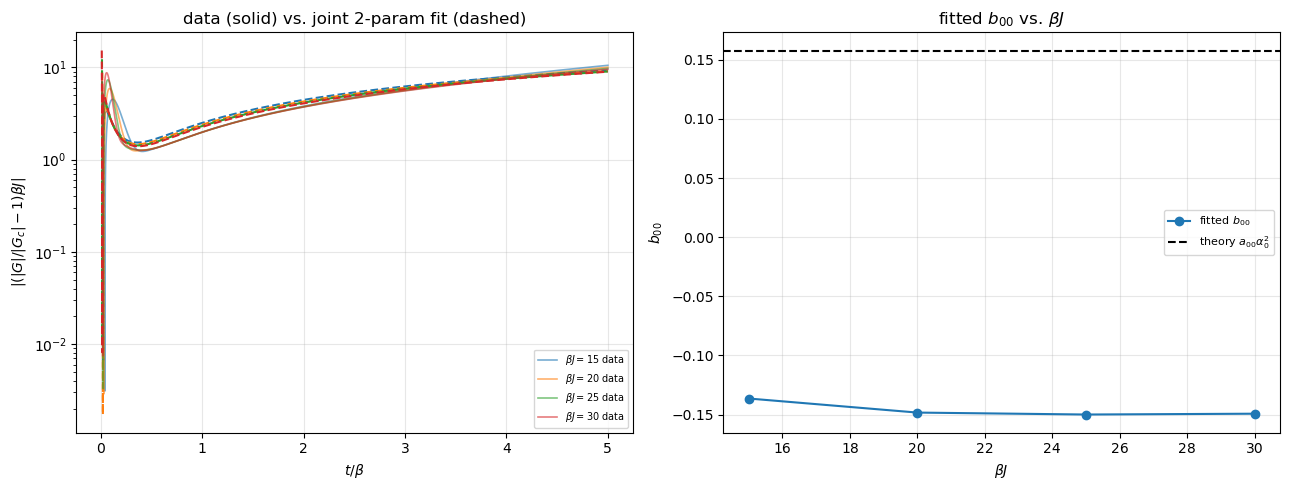

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

fit_rows = []
theory_b00 = a00 * alpha0_original**2

for _, row in df_eq_plot.sort_values("beta").iterrows():
    J = float(row["J4"])
    beta = float(row["beta"])
    t, G = load_G0t(row["filename"])

    x = t / beta
    x_min_row = 3 * uv_t_plot_min(J=J) / beta
    ratio = np.abs(np.imag(G)) / Gc_im_abs(t, beta, J)
    y = (ratio - 1) * beta * J

    keep = np.isfinite(y) & (x >= x_min_row) & (x <= x_plot_max)

    basis = np.column_stack([f_h0(x[keep]), f_00(x[keep]) / (beta * J)])
    coef, *_ = np.linalg.lstsq(basis, y[keep], rcond=None)
    b0, b00 = coef
    pred = basis @ coef

    fit_rows.append({"betaJ": beta * J, "b0": b0, "b00": b00, "b00_over_theory": b00 / theory_b00})

    colour = ax1.plot(x[keep], np.abs(y[keep]), lw=1.2, alpha=0.6, label=rf"$\beta J={beta*J:g}$ data")[0].get_color()
    ax1.plot(x[keep], np.abs(pred), "--", lw=1.5, color=colour)

ax1.set_yscale("log")
ax1.set_xlabel(r"$t/\beta$")
ax1.set_ylabel(r"$|(|G|/|G_c|-1)\beta J|$")
ax1.set_title("data (solid) vs. joint 2-param fit (dashed)")
ax1.grid(alpha=0.3)
ax1.legend(fontsize=7)

fit_df = pd.DataFrame(fit_rows)
display(fit_df)

ax2.plot(fit_df["betaJ"], fit_df["b00"], "o-", label=r"fitted $b_{00}$")
ax2.axhline(theory_b00, color="black", ls="--", label=r"theory $a_{00}\alpha_0^2$")
ax2.set_xlabel(r"$\beta J$")
ax2.set_ylabel(r"$b_{00}$")
ax2.set_title(r"fitted $b_{00}$ vs. $\beta J$")
ax2.grid(alpha=0.3)
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()


### Same plot again, but $b_0=\alpha_0$ fixed to the paper value, only $b_{00}$ fit numerically

Middle ground between the two previous versions: cell 21 fixes *both* $b_0=\alpha_0$ and uses the
*theoretical* $a_{00}\alpha_0^2$; the joint-fit cell above lets *both* $b_0,b_{00}$ float. Here
$b_0=\alpha_0=0.2648$ (paper value) stays fixed as before, but $b_{00}$ is fit by 1-parameter
least squares against the residual $(|G|/|G_c|-1)\beta J - \alpha_0f_{h_0}(x)$, rather than
taken from the theoretical $a_{00}\alpha_0^2$.

,betaJ,b0_fixed,b00_fit
0,15.0,0.2648,-0.000378
1,20.0,0.2648,-0.055865
2,25.0,0.2648,-0.087213
3,30.0,0.2648,-0.104364


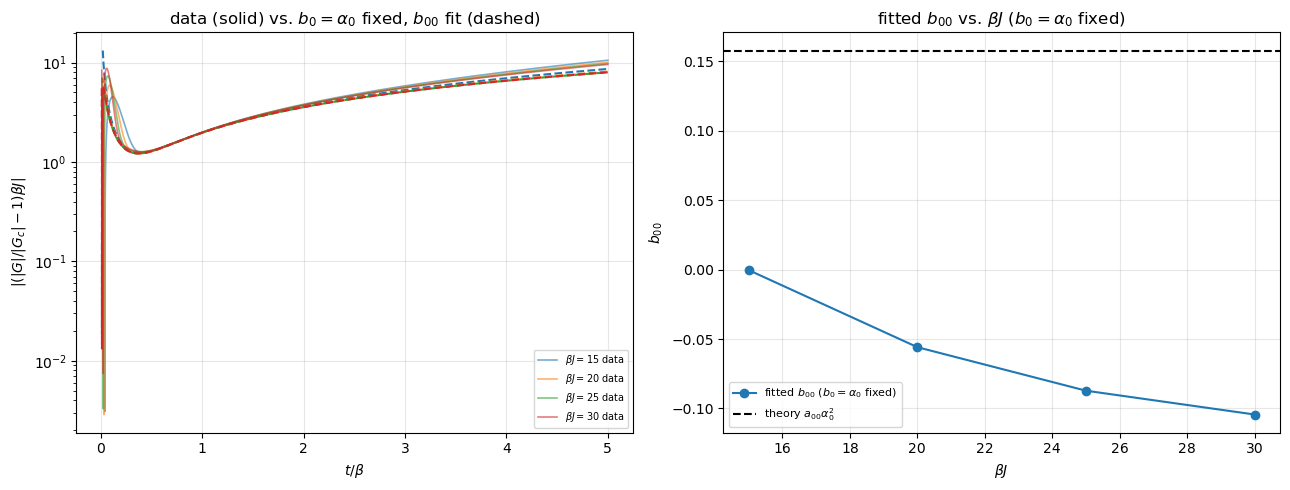

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

fit_rows_fixed = []
theory_b00 = a00 * alpha0_original**2

for _, row in df_eq_plot.sort_values("beta").iterrows():
    J = float(row["J4"])
    beta = float(row["beta"])
    t, G = load_G0t(row["filename"])

    x = t / beta
    x_min_row = 3 * uv_t_plot_min(J=J) / beta
    ratio = np.abs(np.imag(G)) / Gc_im_abs(t, beta, J)
    y = (ratio - 1) * beta * J

    keep = np.isfinite(y) & (x >= x_min_row) & (x <= x_plot_max)

    # b0 fixed to the paper's alpha0; fit only b00 by 1-parameter least squares
    leading_fixed = alpha0_original * f_h0(x[keep])
    residual_1param = y[keep] - leading_fixed
    f = f_00(x[keep]) / (beta * J)
    b00_fit = np.dot(f, residual_1param) / np.dot(f, f)
    pred = leading_fixed + b00_fit * f

    fit_rows_fixed.append({"betaJ": beta * J, "b0_fixed": alpha0_original, "b00_fit": b00_fit})

    colour = ax1.plot(x[keep], np.abs(y[keep]), lw=1.2, alpha=0.6, label=rf"$\beta J={beta*J:g}$ data")[0].get_color()
    ax1.plot(x[keep], np.abs(pred), "--", lw=1.5, color=colour)

ax1.set_yscale("log")
ax1.set_xlabel(r"$t/\beta$")
ax1.set_ylabel(r"$|(|G|/|G_c|-1)\beta J|$")
ax1.set_title(r"data (solid) vs. $b_0=\alpha_0$ fixed, $b_{00}$ fit (dashed)")
ax1.grid(alpha=0.3)
ax1.legend(fontsize=7)

fit_df_fixed = pd.DataFrame(fit_rows_fixed)
display(fit_df_fixed)

ax2.plot(fit_df_fixed["betaJ"], fit_df_fixed["b00_fit"], "o-", label=r"fitted $b_{00}$ ($b_0=\alpha_0$ fixed)")
ax2.axhline(theory_b00, color="black", ls="--", label=r"theory $a_{00}\alpha_0^2$")
ax2.set_xlabel(r"$\beta J$")
ax2.set_ylabel(r"$b_{00}$")
ax2.set_title(r"fitted $b_{00}$ vs. $\beta J$ ($b_0=\alpha_0$ fixed)")
ax2.grid(alpha=0.3)
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()


### Analogous "subtract the leading $h=2$ term" plot, using the numerically-fit $b_{00}$

Same construction as the "Plot after subtracting the leading $h=2$ contribution" cell above
($b_0=\alpha_0$ still fixed there too), but the reference overlay now uses the $b_{00}$ *fit* in
the previous cell instead of the theoretical $a_{00}\alpha_0^2$.

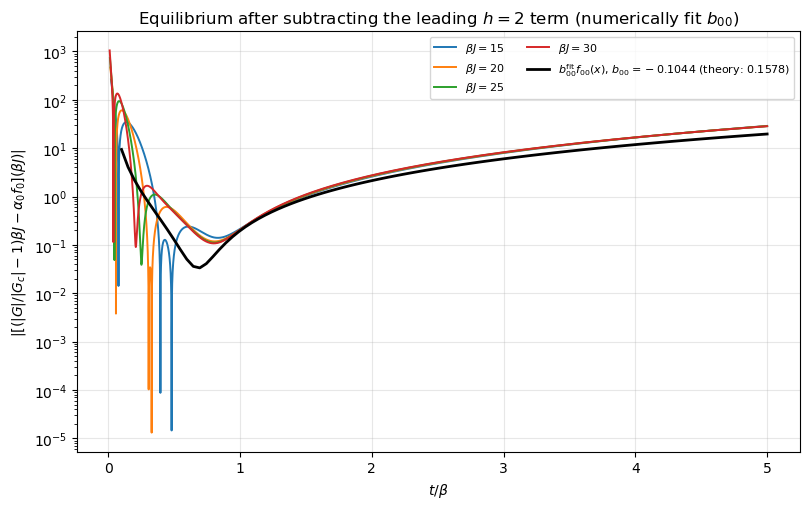

In [16]:
fig, ax = plt.subplots(figsize=(8.2, 5.2))

for _, row in df_eq_plot.sort_values("beta").iterrows():
    J = float(row["J4"])
    beta = float(row["beta"])
    t, G = load_G0t(row["filename"])

    x = t / beta
    x_min_row = 3*uv_t_plot_min(J=J) / beta
    ratio = np.abs(np.imag(G)) / Gc_im_abs(t, beta, J)

    leading = alpha0_original * f_h0(x)
    residual = ((ratio - 1) * beta * J - leading) * beta * J

    keep = (
        np.isfinite(residual)
        & (np.abs(residual) > 0)
        & (x >= x_min_row)
        & (x <= x_plot_max)
    )

    ax.plot(
        x[keep],
        np.abs(residual[keep]),
        lw=1.4,
        label=rf"$\beta J={beta * J:g}$",
    )

# reference curve uses the numerically-fit b00 (largest-betaJ row), not the theoretical a00*alpha0^2
b00_ref = float(fit_df_fixed.sort_values("betaJ")["b00_fit"].iloc[-1])
ax.plot(
    np.linspace(0.1, 5, 100),
    np.abs(b00_ref * f_00(np.linspace(0.1, 5, 100))),
    color="black",
    lw=2,
    label=rf"$b_{{00}}^{{\rm fit}}f_{{00}}(x)$, $b_{{00}}={b00_ref:.4f}$ (theory: {theory_b00:.4f})",
)

ax.set_yscale("log")
ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(
    r"$|[(|G|/|G_c|-1)\beta J-\alpha_0 f_0](\beta J)|$"
)
ax.set_title(r"Equilibrium after subtracting the leading $h=2$ term (numerically fit $b_{00}$)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


### Testing the $h_1$ channel instead: does the next term match $\alpha_1f_{h_1}(x)$?

$h_1-1\approx2.77$ is *less* than the $h_{000}$ descendant's order (3), so the $h_1$ channel
should actually decay slower and dominate over $h_{000}$ at these $\beta J$ -- the previous cell
used the wrong rescaling power (assumed order-3). After subtracting $h=2$ and $h_{00}$,

$$\text{residual}_{h2} - b_{00}f_{00}(x) = \alpha_1f_{h_1}(x)/(\beta J)^{h_1-3} + \cdots$$

so multiplying by $(\beta J)^{h_1-3}$ (not another full $\beta J^1$) is what should reveal
$\alpha_1f_{h_1}(x)$ as the leading, roughly $\beta J$-independent piece. Using the paper's
$\alpha_1=0.32679563$ directly (no numerical fit) as the overlay.

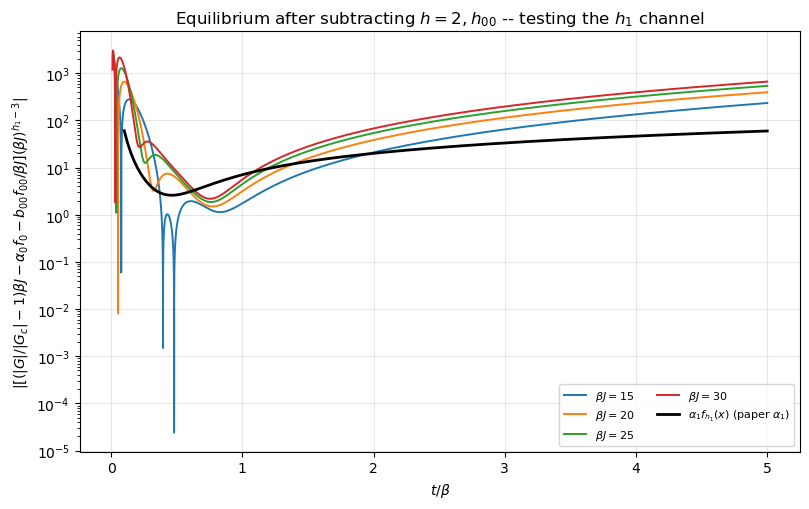

In [17]:
fig, ax = plt.subplots(figsize=(8.2, 5.2))

b00_by_beta = fit_df_fixed.set_index("betaJ")["b00_fit"]

for _, row in df_eq_plot.sort_values("beta").iterrows():
    J = float(row["J4"])
    beta = float(row["beta"])
    t, G = load_G0t(row["filename"])

    x = t / beta
    x_min_row = 3 * uv_t_plot_min(J=J) / beta
    ratio = np.abs(np.imag(G)) / Gc_im_abs(t, beta, J)

    leading = alpha0_original * f_h0(x)
    residual_h2 = ((ratio - 1) * beta * J - leading) * beta * J  # same as cell 21/27

    b00_this = b00_by_beta.loc[beta * J]
    betaJ = beta * J
    residual_h1_reveal = (residual_h2 - b00_this * f_00(x)) * betaJ ** (H1 - 3.0)

    keep = (
        np.isfinite(residual_h1_reveal)
        & (np.abs(residual_h1_reveal) > 0)
        & (x >= x_min_row)
        & (x <= x_plot_max)
    )

    ax.plot(
        x[keep],
        np.abs(residual_h1_reveal[keep]),
        lw=1.4,
        label=rf"$\beta J={betaJ:g}$",
    )

x_ref = np.linspace(0.1, 5, 200)
ax.plot(x_ref, np.abs(alpha1 * f_h1(x_ref)), color="black", lw=2,
        label=r"$\alpha_1f_{h_1}(x)$ (paper $\alpha_1$)")

ax.set_yscale("log")
ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(
    r"$|[(|G|/|G_c|-1)\beta J-\alpha_0 f_0-b_{00}f_{00}/\beta J](\beta J)^{h_1-3}|$"
)
ax.set_title(r"Equilibrium after subtracting $h=2,h_{00}$ -- testing the $h_1$ channel")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


## 3. Engineered-kernel equilibrium curves and odd-in-$\lambda$ response


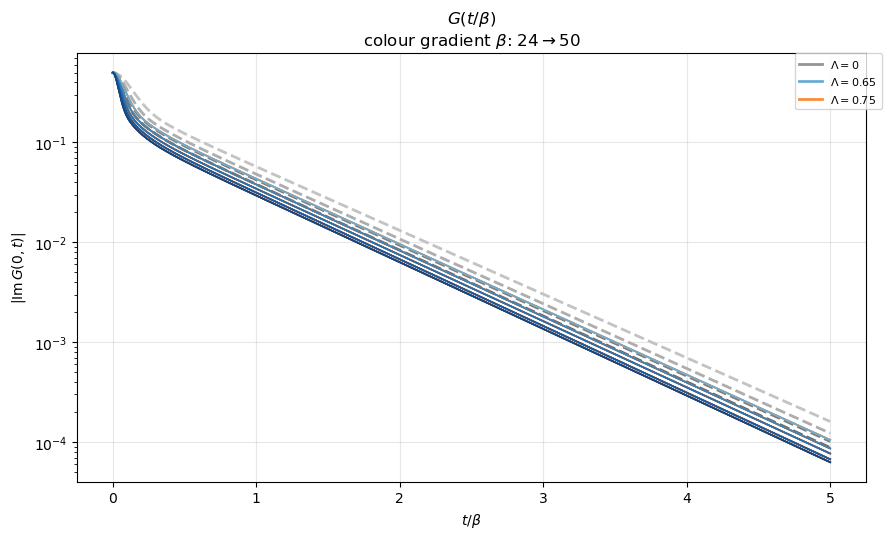

In [18]:
fig, ax = plt.subplots(figsize=(9, 5.5))

lambdas = sorted({0.0} | set(df_kernel_plot["kernel_cutoff"].unique()))
betas = sorted(set(df_eq_plot["beta"].unique()) | set(df_kernel_plot["beta"].unique()))

for _, row in df_eq_plot.sort_values("beta").iterrows():
    t, G = load_G0t(row["filename"])
    beta = row["beta"]
    x = t / beta
    keep = (x >= 0) & (x <= x_plot_max)

    ax.plot(x[keep], np.abs(np.imag(G[keep])), "--", lw=2,color=_colour_for(0.0, beta, lambdas, betas),)

for _, row in df_kernel_plot.sort_values(
    ["kernel_lambda", "kernel_delta", "beta"]
).iterrows():
    t, G = load_G0t(row["filename"])
    beta = row["beta"]
    x = t / beta
    x_min_row = uv_t_plot_min(Lambda=row["kernel_cutoff"]) / beta
    keep = (x >= 0) & (x <= x_plot_max)

    ax.plot(
        x[keep], np.abs(np.imag(G[keep])), lw=1.2,
        color=_colour_for(row["kernel_cutoff"], beta, lambdas, betas),
    )

handles = [
    Line2D(
        [0], [0], color=_colour_for(L, betas[2], lambdas, betas), lw=2,
        label=(r"$\Lambda=0$" if np.isclose(L, 0.0) else rf"$\Lambda={L:g}$"),
    )
    for L in lambdas
]

ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(r"$|\operatorname{Im}G(0,t)|$")
ax.set_title(r"$G(t/\beta)$"+"\n" + r"colour gradient $\beta$: " + f"{beta_keep_kernel[0]:1g}"+r"$\to$" +f"{beta_keep_kernel[-1]:1g}")
ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, fontsize=8)
fig.tight_layout()
plt.show()


### Fit function: pair $\pm\lambda$ runs and jointly fit $b_0,b_1$

Builds $(\beta J)D_\lambda(x)$ for every retained $(\beta,\delta,\Lambda)$ and fits it to the
two-template model $b_0\,f_0(x)+b_1\,f_1(x)/(\beta J)^{h_1-2}$ by linear least squares
(complex: the fit tracks both the real amplitude and the small "quadrature" component, as the
original single-template fit did).


In [19]:
def build_kernel_odd_response(
    *, beta_keep, lambda_keep, delta_keep, cutoff_keep,
    fit_x_max=h0_fit_x_max, plot=True, show_fit_overlay=True, beta_rescale=0,
):
    pair_source = df_kernel_all.copy()
    pair_source["abs_lambda"] = np.abs(pair_source["kernel_lambda"])
    pair_source["lambda_sign"] = np.sign(pair_source["kernel_lambda"])

    mask = (
        np.isclose(pair_source["J4"], J4_keep)
        & np.isclose(pair_source["mu"], 0.0)
        & (pair_source["abs_lambda"] > 0)
        & selected(pair_source["beta"], beta_keep)
        & selected(pair_source["abs_lambda"], lambda_keep)
        & selected_pairs(
            pair_source["kernel_delta"], pair_source["kernel_cutoff"],
            delta_keep, cutoff_keep,
        )
    )
    pair_source = pair_source[mask]

    physical_keys = [
        "J2", "J4", "beta", "mu", "abs_lambda", "kernel_delta", "kernel_cutoff",
    ]
    resolution_keys = ["dt", "Nw", "omega_max"]

    plus = pair_source[pair_source["lambda_sign"] > 0]
    minus = pair_source[pair_source["lambda_sign"] < 0]
    pairs = (
        plus.merge(minus, on=physical_keys + resolution_keys, suffixes=("_plus", "_minus"))
        .sort_values(
            physical_keys + resolution_keys,
            ascending=[True] * len(physical_keys) + [True, False, False],
        )
        .drop_duplicates(physical_keys)
        .reset_index(drop=True)
    )
    if pairs.empty:
        raise RuntimeError("No +/- lambda pairs match the requested filters.")

    lambdas = sorted(pairs["kernel_cutoff"].unique())
    betas = sorted(pairs["beta"].unique())

    rows = []
    fig, ax = (plt.subplots(figsize=(9, 5.5)) if plot else (None, None))

    for _, row in pairs.iterrows():
        J, beta, lam = float(row["J4"]), float(row["beta"]), float(row["abs_lambda"])
        Lambda, betaJ = float(row["kernel_cutoff"]), beta * J

        t, G_plus = load_G0t(row["filename_plus"])
        t_minus, G_minus = load_G0t(row["filename_minus"])
        assert np.allclose(t, t_minus)

        x = t / beta
        D_odd = (G_plus - G_minus) / (2 * lam * Gc_complex(t, beta, J))
        scaled = D_odd * betaJ  # (beta J) D_lambda(x)

        x_min_row = uv_t_plot_min(Lambda=Lambda) / beta
        fit = (
            np.isfinite(np.real(scaled)) & np.isfinite(np.imag(scaled))
            & (x >= fit_x_min_for(x_min_row)) & (x <= fit_x_max)
        )
        basis = np.column_stack(
            [f_h0(x[fit]), f_h1_scaled(x[fit], betaJ)]
        ).astype(complex)
        coef, *_ = np.linalg.lstsq(basis, scaled[fit], rcond=None)
        b0, b1 = coef

        residual_rms = float(np.sqrt(np.mean(np.abs(scaled[fit] - basis @ coef) ** 2)))
        data_rms = float(np.sqrt(np.mean(np.abs(scaled[fit]) ** 2)))
        relative_residual = residual_rms / data_rms if data_rms > 0 else np.nan

        keep = np.isfinite(np.real(scaled)) & (x >= x_min_row) & (x <= x_plot_max)

        if plot:
            colour = _colour_for(Lambda, beta, lambdas, betas)
            if beta_rescale==0:
                ax.plot(x[keep], np.abs(scaled[keep]), lw=1.3, color=colour)
                if show_fit_overlay:
                    model = b0 * f_h0(x[keep]) + b1 * f_h1_scaled(x[keep], betaJ)
                    ax.plot(x[keep], np.abs(model), "--", lw=1.0, color=colour)
            elif beta_rescale==None:
                ax.plot(x[keep], np.abs(scaled[keep])/beta, lw=1.3, color=colour)
                if show_fit_overlay:
                    model = b0 * f_h0(x[keep]) + b1 * f_h1_scaled(x[keep], betaJ)
                    ax.plot(x[keep], np.abs(model)/beta, "--", lw=1.0, color=colour)
            elif beta_rescale==1:
                ax.plot(x[keep], np.abs(scaled[keep]) * betaJ**(H1-2.0), lw=1.3, color=colour)
                if show_fit_overlay:
                    model = b0 * f_h0(x[keep]) + b1 * f_h1_scaled(x[keep], betaJ)
                    ax.plot(x[keep], np.abs(model) * betaJ**(H1-2.0), "--", lw=1.0, color=colour)

        rows.append({
            "J4": J, "beta": beta, "betaJ": betaJ, "mu": float(row["mu"]),
            "abs_lambda": lam, "kernel_delta": float(row["kernel_delta"]),
            "kernel_cutoff": Lambda,
            "dt": float(row["dt"]), "Nw": int(row["Nw"]), "omega_max": float(row["omega_max"]),
            "x": x[keep], "scaled_response": scaled[keep],
            "h0_amplitude": float(b0.real), "h0_quadrature": float(b0.imag),
            "h1_amplitude": float(b1.real), "h1_quadrature": float(b1.imag),
            "fit_residual_rms": residual_rms, "fit_relative_residual": relative_residual,
            "filename_plus": row["filename_plus"], "filename_minus": row["filename_minus"],
        })

    df_odd = pd.DataFrame(rows)

    if plot:
        # Reference curves use the largest-(beta J) row's fit, not whatever
        # `b0, b1` happened to be left over from the last loop iteration
        # (that was a stale-variable bug: it silently picked out one
        # arbitrary (beta, Lambda) run rather than a representative one).
        ref_row = df_odd.loc[df_odd["betaJ"].idxmax()]
        betaJ_ref = ref_row["betaJ"]
        b0_ref = ref_row["h0_amplitude"] + 1j * ref_row["h0_quadrature"]
        b1_ref = ref_row["h1_amplitude"] + 1j * ref_row["h1_quadrature"]

        handles = [
            Line2D([0], [0], color=_colour_for(Lambda, betas[1], lambdas, betas),
                   lw=2, label=rf"$\Lambda={Lambda:g}$")
            for Lambda in lambdas
        ]
        ax.set_xlabel(r"$t/\beta$")
        x_ref = np.linspace(0.5, x_plot_max, 300)
        if beta_rescale==0:
            # Reference terms as they actually appear in (beta J) D_lambda(x)
            # for the reference (largest-beta J) row: b0*f_h0 needs no
            # extra factor, b1*f_h1 is suppressed by (beta J)^{-(h1-2)}.
            line_b0, = ax.plot(x_ref, np.abs(b0_ref * f_h0(x_ref)), lw=1.5, color="purple",label=r'$f_0$')
            line_b1, = ax.plot(x_ref, np.abs(b1_ref * f_h1(x_ref)) / betaJ_ref**(H1-2.0)/1.85, lw=1.5, color="black",label=r'$f_{h_1}$')
            ax.set_ylabel(r"$\beta J|D_\lambda|$")
            ax.set_title(
                r"$\beta J |D_\lambda (t/\beta )| = f_0(t/\beta)$ or $ = f_1(t/\beta)/(\beta J)^{h_1-2}$" +
                "\n" + r"colour gradient $\beta$: " + f"{beta_keep_kernel[0]:1g}"+r"$\to$" +f"{beta_keep_kernel[-1]:1g}"
            )
        elif beta_rescale==None:
            line_b0, = ax.plot(x_ref, np.abs(b0_ref * f_h0(x_ref)) / betaJ_ref, lw=1.5, color="purple",label=r'$f_0$')
            line_b1, = ax.plot(x_ref, np.abs(b1_ref * f_h1(x_ref)) / betaJ_ref**(H1-1.0)/1.85, lw=1.5, color="black",label=r'$f_{h_1}$')
            ax.set_ylabel(r"$|D_\lambda(t/\beta)|$")
            ax.set_title(
                r"$|D_\lambda(t/\beta)| =  |G_*(t/\beta)_\lambda-G_*(t/\beta)_{-\lambda}|/2\lambda G_c(t/\beta)$" +
                "\n" + r"colour gradient $\beta$: " + f"{beta_keep_kernel[0]:1g}"+r"$\to$" +f"{beta_keep_kernel[-1]:1g}"
            )
        elif beta_rescale==1:
            line_b0, = ax.plot(x_ref, np.abs(b0_ref * f_h0(x_ref)) * betaJ_ref**(H1-2.0), lw=2, color="purple",label=r'$f_0$')
            line_b1, = ax.plot(x_ref, np.abs(b1_ref * f_h1(x_ref))/1.6, lw=2, color="black",label=r'$f_{h_1}$')
            ax.set_ylabel(r"$(\beta J)^{h_1-1}|D_\lambda|$")
            ax.set_title(
                r"$(\beta J)^{h_1-1} |D_\lambda (t/\beta )| = f(t/\beta)$" +
                "\n" + r"colour gradient $\beta$: " + f"{beta_keep_kernel[0]:1g}"+r"$\to$" +f"{beta_keep_kernel[-1]:1g}"
            )

        handles = handles + [line_b0, line_b1]

        ax.grid(alpha=0.3)
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.07, 1.0),
                   borderaxespad=0.0, fontsize=8)
        plt.show()

    return df_odd


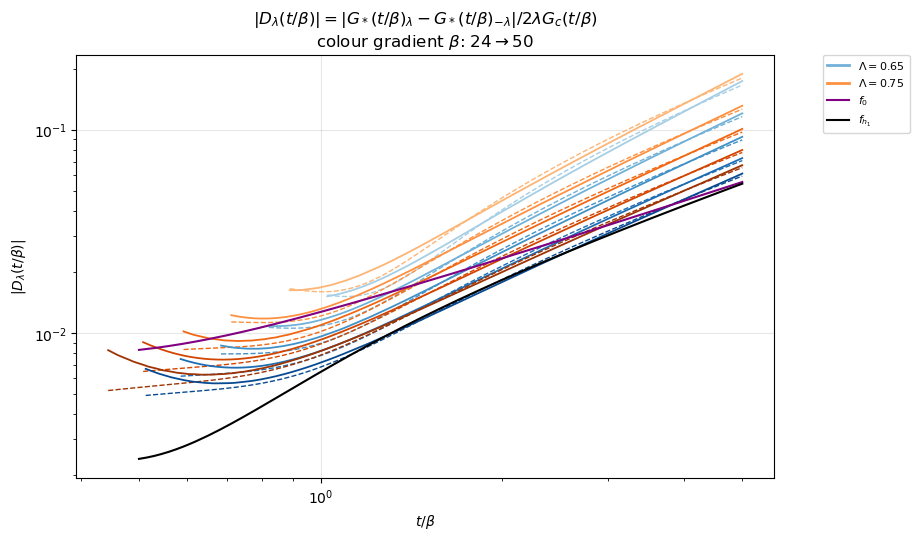

,beta,betaJ,kernel_delta,kernel_cutoff,h0_amplitude,h1_amplitude,fit_relative_residual
1,24.0,24.0,-0.043936,0.65,0.164500,14.262029,0.037243
3,30.0,30.0,-0.043936,0.65,0.102281,15.451291,0.031381
5,36.0,36.0,-0.043936,0.65,0.073662,17.579157,0.029449
7,42.0,42.0,-0.043936,0.65,0.053618,19.398204,0.024075
9,48.0,48.0,-0.043936,0.65,0.043801,22.280986,0.023906
0,24.0,24.0,-0.053648,0.75,0.153071,14.197582,0.038937
2,30.0,30.0,-0.053648,0.75,0.096676,15.735174,0.032059
4,36.0,36.0,-0.053648,0.75,0.069615,18.093641,0.029684
6,42.0,42.0,-0.053648,0.75,0.051813,20.336847,0.024247
8,48.0,48.0,-0.053648,0.75,0.041613,23.391853,0.024403


In [20]:
df_kernel_odd = build_kernel_odd_response(
    beta_keep=beta_keep_kernel,
    lambda_keep=lambda_keep,
    delta_keep=delta_keep,
    cutoff_keep=cutoff_keep,
    beta_rescale=None
)

display(df_kernel_odd[[
    "beta", "betaJ", "kernel_delta", "kernel_cutoff",
    "h0_amplitude", "h1_amplitude", "fit_relative_residual",
]].sort_values(["kernel_cutoff", "kernel_delta", "beta"]))


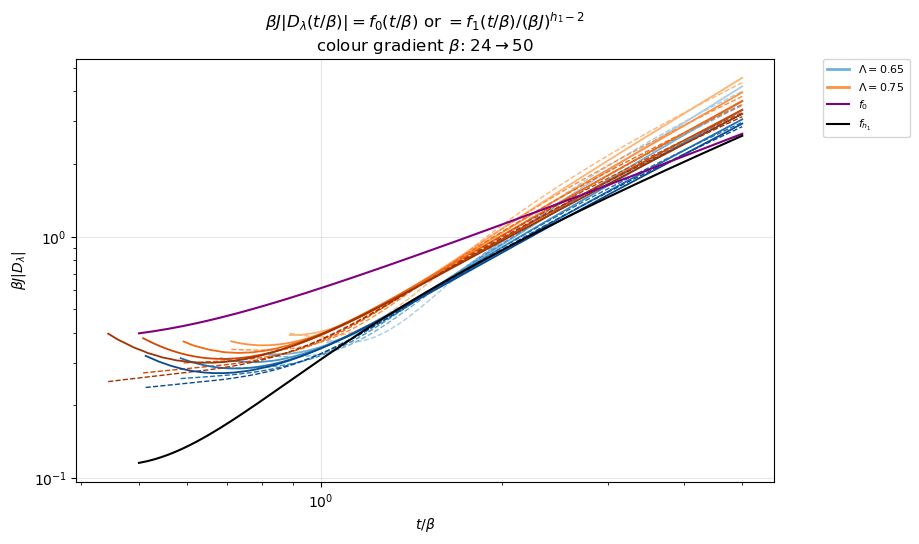

In [21]:
df_kernel_odd = build_kernel_odd_response(
    beta_keep=beta_keep_kernel,
    lambda_keep=lambda_keep,
    delta_keep=delta_keep,
    cutoff_keep=cutoff_keep,
)

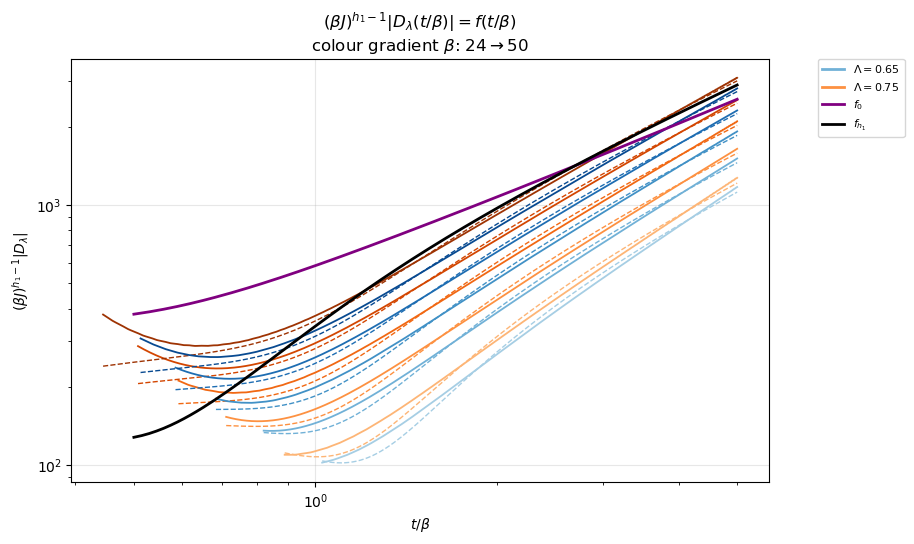

In [22]:
df_kernel_odd = build_kernel_odd_response(
    beta_keep=beta_keep_kernel,
    lambda_keep=lambda_keep,
    delta_keep=delta_keep,
    cutoff_keep=cutoff_keep,
    beta_rescale=1
)

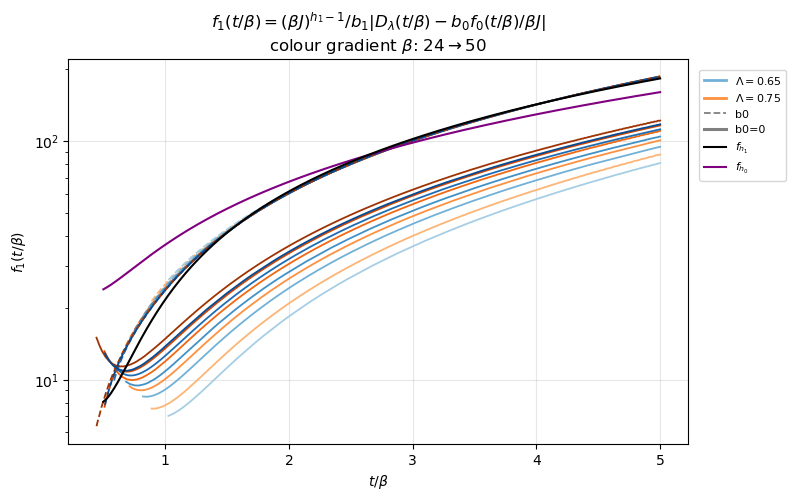

In [262]:
# Rescaled by (beta J)^(h1-2) so that -- if the fit is good -- what's left
# is ~ b1*f_1(t/beta). Thick = raw (b0 not subtracted); dashed = with
# b0*f_0 subtracted; black = fit reference b1*f_1(x).

fig, ax = plt.subplots(figsize=(8, 5))

lambdas = sorted(df_kernel_odd["kernel_cutoff"].unique())
betas = sorted(df_kernel_odd["beta"].unique())

for _, row in df_kernel_odd.iterrows():
    x = np.asarray(row["x"])
    scaled = np.asarray(row["scaled_response"])
    betaJ = row["betaJ"]
    colour = _colour_for(row["kernel_cutoff"], row["beta"], lambdas, betas)

    h0_term = (row["h0_amplitude"] + 1j * row["h0_quadrature"]) * f_h0(x)

    raw = betaJ ** (H1 - 2.0) * scaled
    subtracted = betaJ ** (H1 - 2.0) * (scaled - h0_term)

    ax.plot(x, np.abs(raw/(row["h1_amplitude"] + 1j * row["h1_quadrature"])), lw=1.3, color=colour)
    ax.plot(x, np.abs(subtracted/(row["h1_amplitude"] + 1j * row["h1_quadrature"]) ), lw=1.3, linestyle="--", color=colour)

# Reference fit curve b1*f_1(x), using the largest-(beta J) row available.
ref_row = df_kernel_odd.loc[df_kernel_odd["betaJ"].idxmax()]
b1_ref = ref_row["h1_amplitude"] + 1j * ref_row["h1_quadrature"]
b0_ref = ref_row["h0_amplitude"] + 1j * ref_row["h0_quadrature"]
x_ref = np.linspace(0.5, x_plot_max, 300)
line_f_h0, = ax.plot(x_ref, np.abs(50**1.77*1.5*b0_ref * f_h0(x_ref)/b1_ref), lw=1.5, color="purple", label=r"$f_{h_0}$")
line_f_h1, = ax.plot(x_ref, np.abs( f_h1(x_ref)), lw=1.5, color="black", label=r"$f_{h_1}$")

# Each Lambda can now carry more than one delta (multiple engineered-kernel
# runs share a cutoff), so collect all deltas seen at that Lambda rather
# than formatting the whole kernel_delta column (which raised
# "unsupported format string passed to Series.__format__").
lambda_handles = []
for L in lambdas:
    deltas_for_L = sorted(
        df_kernel_odd.loc[np.isclose(df_kernel_odd["kernel_cutoff"], L), "kernel_delta"].unique()
    )
    delta_str = ", ".join(f"{d:g}" for d in deltas_for_L)
    lambda_handles.append(
        Line2D([0], [0], color=_colour_for(L, betas[1], lambdas, betas), lw=2,
               label=rf"$\Lambda={L:g}$")
    )
style_handles = [
    #Line2D([0], [0], color="black", lw=1.5, label="fit"),
    Line2D([0], [0], color="grey", lw=1.3, linestyle="--", label="b0"),
    Line2D([0], [0], color="grey", lw=2.2, label="b0=0"),
    line_f_h1,
    line_f_h0,
]

ax.set_xlabel(r"$t/\beta$")
ax.set_ylabel(r"$f_1(t/\beta)$")
ax.set_title(
    r"$f_1(t/\beta) =  (\beta J)^{h_1-1} /b_1 |D_\lambda(t/\beta) -b_0 f_0(t/\beta)/\beta J|$"
    "\n" + r"colour gradient $\beta$: " + f"{beta_keep_kernel[0]:1g}"+r"$\to$" +f"{beta_keep_kernel[-1]:1g}"
)
ax.set_yscale("log")
#ax.set_xscale("log")
ax.grid(alpha=0.3)
ax.legend(
    handles=lambda_handles + style_handles, loc="upper left",
    bbox_to_anchor=(1.0, 1.0), borderaxespad=1.0, fontsize=8,
)

plt.show()


### Per-$\beta$ fit with $b_0$ fixed to zero: fit only $b_1$

Same per-$(\beta,\delta,\Lambda)$ pairing and fit window as
`build_kernel_odd_response` above, but $b_0$ is fixed to $0$ and only $b_1$ is
fit -- a one-parameter complex least squares of $(\beta J)D_\lambda(x)$
against $f_{h_1}(x)/(\beta J)^{h_1-2}$ alone, one $\beta$ at a time. This
checks whether the $h_1$ template by itself already accounts for the odd
response at each $\beta J$, without any $h_0$ contamination (contrast with
the pooled fit above, which shares one $b_0,b_1$ across all $\beta$).

In [23]:
def build_kernel_odd_response_b0_zero(
    *, beta_keep, lambda_keep, delta_keep, cutoff_keep,
    fit_x_max=h0_fit_x_max, plot=True, show_fit_overlay=True,
):
    pair_source = df_kernel_all.copy()
    pair_source["abs_lambda"] = np.abs(pair_source["kernel_lambda"])
    pair_source["lambda_sign"] = np.sign(pair_source["kernel_lambda"])

    mask = (
        np.isclose(pair_source["J4"], J4_keep)
        & np.isclose(pair_source["mu"], 0.0)
        & (pair_source["abs_lambda"] > 0)
        & selected(pair_source["beta"], beta_keep)
        & selected(pair_source["abs_lambda"], lambda_keep)
        & selected_pairs(
            pair_source["kernel_delta"], pair_source["kernel_cutoff"],
            delta_keep, cutoff_keep,
        )
    )
    pair_source = pair_source[mask]

    physical_keys = [
        "J2", "J4", "beta", "mu", "abs_lambda", "kernel_delta", "kernel_cutoff",
    ]
    resolution_keys = ["dt", "Nw", "omega_max"]

    plus = pair_source[pair_source["lambda_sign"] > 0]
    minus = pair_source[pair_source["lambda_sign"] < 0]
    pairs = (
        plus.merge(minus, on=physical_keys + resolution_keys, suffixes=("_plus", "_minus"))
        .sort_values(
            physical_keys + resolution_keys,
            ascending=[True] * len(physical_keys) + [True, False, False],
        )
        .drop_duplicates(physical_keys)
        .reset_index(drop=True)
    )
    if pairs.empty:
        raise RuntimeError("No +/- lambda pairs match the requested filters.")

    lambdas = sorted(pairs["kernel_cutoff"].unique())
    betas = sorted(pairs["beta"].unique())

    rows = []
    fig, ax = (plt.subplots(figsize=(9, 5.5)) if plot else (None, None))

    for _, row in pairs.iterrows():
        J, beta, lam = float(row["J4"]), float(row["beta"]), float(row["abs_lambda"])
        Lambda, betaJ = float(row["kernel_cutoff"]), beta * J

        t, G_plus = load_G0t(row["filename_plus"])
        t_minus, G_minus = load_G0t(row["filename_minus"])
        assert np.allclose(t, t_minus)

        x = t / beta
        D_odd = (G_plus - G_minus) / (2 * lam * Gc_complex(t, beta, J))
        scaled = D_odd * betaJ  # (beta J) D_lambda(x)

        x_min_row = uv_t_plot_min(Lambda=Lambda) / beta
        fit = (
            np.isfinite(np.real(scaled)) & np.isfinite(np.imag(scaled))
            & (x >= fit_x_min_for(x_min_row)) & (x <= fit_x_max)
        )
        # f_h1_scaled is real-valued, so the complex least-squares
        # projection onto it alone reduces to this dot-product ratio.
        f1 = f_h1_scaled(x[fit], betaJ)
        b1 = np.dot(f1, scaled[fit]) / np.dot(f1, f1)

        residual_rms = float(np.sqrt(np.mean(np.abs(scaled[fit] - b1 * f1) ** 2)))
        data_rms = float(np.sqrt(np.mean(np.abs(scaled[fit]) ** 2)))
        relative_residual = residual_rms / data_rms if data_rms > 0 else np.nan

        keep = np.isfinite(np.real(scaled)) & (x >= x_min_row) & (x <= x_plot_max)

        if plot:
            colour = _colour_for(Lambda, beta, lambdas, betas)
            ax.plot(x[keep], np.abs(scaled[keep])*betaJ**(H1-2), lw=1.3, color=colour)
            if show_fit_overlay and betaJ==48:
                model = b1 * f_h1_scaled(x[keep], betaJ)
                ax.plot(x[keep], np.abs(model)*betaJ**(H1-2), "--", lw=1.0, color=colour)

        rows.append({
            "J4": J, "beta": beta, "betaJ": betaJ, "mu": float(row["mu"]),
            "abs_lambda": lam, "kernel_delta": float(row["kernel_delta"]),
            "kernel_cutoff": Lambda,
            "dt": float(row["dt"]), "Nw": int(row["Nw"]), "omega_max": float(row["omega_max"]),
            "x": x[keep], "scaled_response": scaled[keep],
            "h0_amplitude": 0.0, "h0_quadrature": 0.0,
            "h1_amplitude": float(b1.real), "h1_quadrature": float(b1.imag),
            "fit_residual_rms": residual_rms, "fit_relative_residual": relative_residual,
            "filename_plus": row["filename_plus"], "filename_minus": row["filename_minus"],
        })

    df_odd = pd.DataFrame(rows)

    if plot:
        ref_row = df_odd.loc[df_odd["betaJ"].idxmax()]
        betaJ_ref = ref_row["betaJ"]
        b1_ref = ref_row["h1_amplitude"] + 1j * ref_row["h1_quadrature"]

        handles = [
            Line2D([0], [0], color=_colour_for(Lambda, betas[1], lambdas, betas),
                   lw=2, label=rf"$\Lambda={Lambda:g}$")
            for Lambda in lambdas
        ]
        ax.set_xlabel(r"$t/\beta$")
        x_ref = np.linspace(0.6, x_plot_max, 300)
        line_b0, = ax.plot(
            x_ref, np.abs(5*b1_ref * f_h0(x_ref)) / betaJ_ref ** (0*(H1 - 2.0)),
            lw=2, color="purple", label=r"$f_{h_0}$",
        )
        line_b1, = ax.plot(
            x_ref, np.abs(b1_ref * f_h1(x_ref)) / betaJ_ref ** (0*(H1 - 2.0)),
            lw=2, color="black", label=r"$f_{h_1}$",
        )
        ax.set_ylabel(r"$(\beta J)^{h_1-1}|D_\lambda|$")
        ax.set_title(
            r"$(\beta J)^{h_1-1}|D_\lambda(t/\beta)| = f_1(t/\beta)$, $b_0\equiv0$"
            "\n" + r"colour gradient $\beta$: " + f"{beta_keep_kernel[0]:1g}"+r"$\to$" +f"{beta_keep_kernel[-1]:1g}"
        )
        handles = handles + [
            line_b0, line_b1,
            Line2D([0], [0], color="grey", lw=1.0, linestyle="--",
                   label=r"fit ( $f_{h_0}, f_{h_1}$ )"),
        ]
        ax.grid(alpha=0.3)
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.07, 1.0),
                   borderaxespad=0.0, fontsize=8)
        plt.show()

    return df_odd

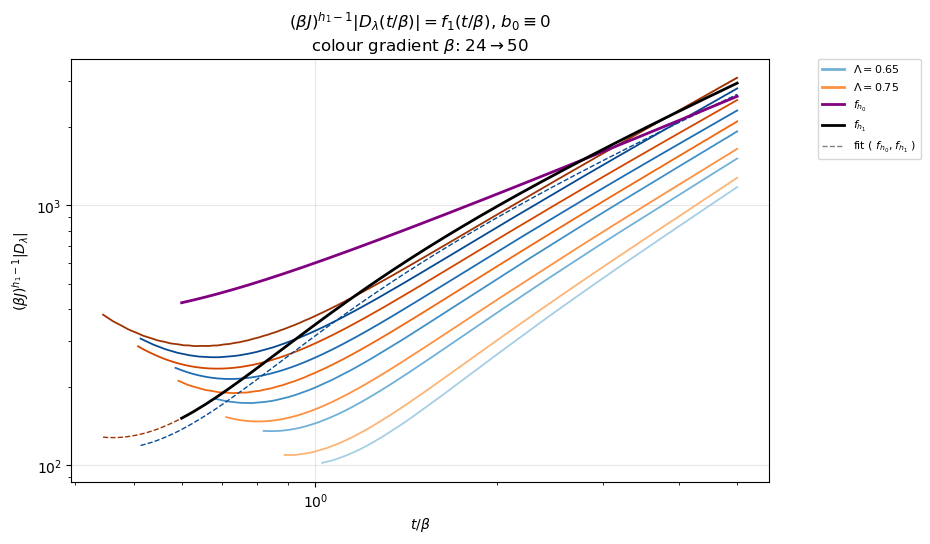

In [24]:
df_kernel_odd_b0zero = build_kernel_odd_response_b0_zero(
    beta_keep=beta_keep_kernel,
    lambda_keep=lambda_keep,
    delta_keep=delta_keep,
    cutoff_keep=cutoff_keep,
    show_fit_overlay=True,
    
)

## 4. Real time templates of $f_n(x = t/\beta)$ and fitt $b_0,b_1$ vs $\beta J$

`build_kernel_odd_response` fits $b_0,b_1$ independently for every retained
$(\beta,\delta,\Lambda)$ row (one linear least-squares solve per row), so the
fit already *is* per-$\beta J$. The plots below make that dependence explicit,
grouped by $(\delta,\Lambda)$, and then show the fitted templates
$b_0f_{h_0}(x)/\beta^{h_0-1}$ and $b_1f_{h_1}(x)/\beta^{h_1-1}$ the same
way the bare templates were shown above.

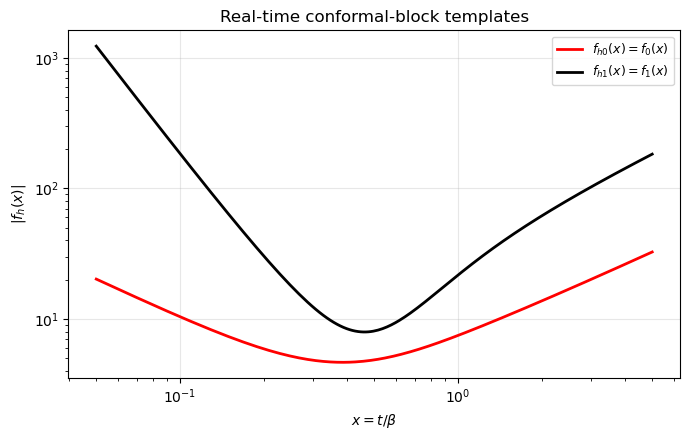

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

x_template = np.linspace(0.05, 5.0, 500)

ax.plot(x_template, np.abs(f_h0(x_template)), lw=2, color="red", label=r"$f_{h0}(x)=f_0(x)$")
ax.plot(x_template, np.abs(f_h1(x_template)), lw=2, color="black", label=r"$f_{h1}(x)=f_1(x)$")

ax.set_xlabel(r"$x=t/\beta$")
ax.set_ylabel(r"$|f_h(x)|$")
ax.set_title("Real-time conformal-block templates")
ax.set_yscale("log")
ax.set_xscale("log")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

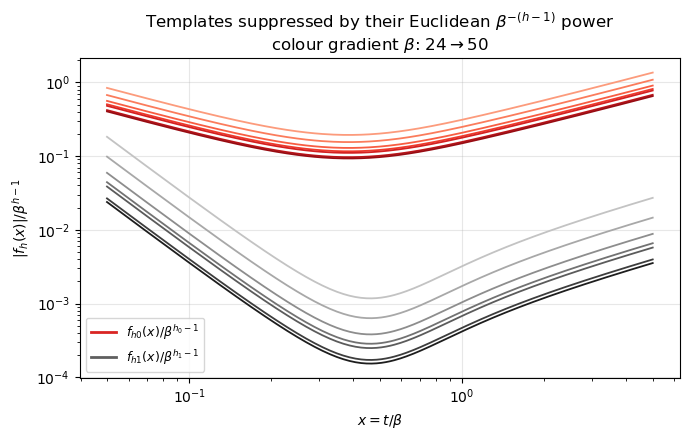

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

H0 = 2.0
betas_template = beta_keep_kernel  # J4_keep == 1.0, so beta == beta*J here

cmap_h0 = plt.colormaps["Reds"]
cmap_h1 = plt.colormaps["Greys"]

for i, beta in enumerate(betas_template):
    shade = 0.35 + 0.55 * i / max(len(betas_template) - 1, 1)
    ax.plot(
        x_template, np.abs(f_h0(x_template)) / beta ** (H0 - 1),
        lw=1.3, color=cmap_h0(shade),
    )
    ax.plot(
        x_template, np.abs(f_h1(x_template)) / beta ** (H1 - 1),
        lw=1.3, color=cmap_h1(shade),
    )

handles = [
    Line2D([0], [0], color=cmap_h0(0.7), lw=2, label=r"$f_{h0}(x)/\beta^{h_0-1}$"),
    Line2D([0], [0], color=cmap_h1(0.7), lw=2, label=r"$f_{h1}(x)/\beta^{h_1-1}$"),
]

ax.set_xlabel(r"$x=t/\beta$")
ax.set_ylabel(r"$|f_h(x)|/\beta^{h-1}$")
ax.set_title(
    r"Templates suppressed by their Euclidean $\beta^{-(h-1)}$ power"
    "\n" + r"colour gradient $\beta$: " + f"{beta_keep_kernel[0]:g}" + r"$\to$" + f"{beta_keep_kernel[-1]:g}"
)
ax.set_yscale("log")
ax.set_xscale("log")
ax.grid(alpha=0.3)
ax.legend(handles=handles, fontsize=9)
fig.tight_layout()
plt.show()

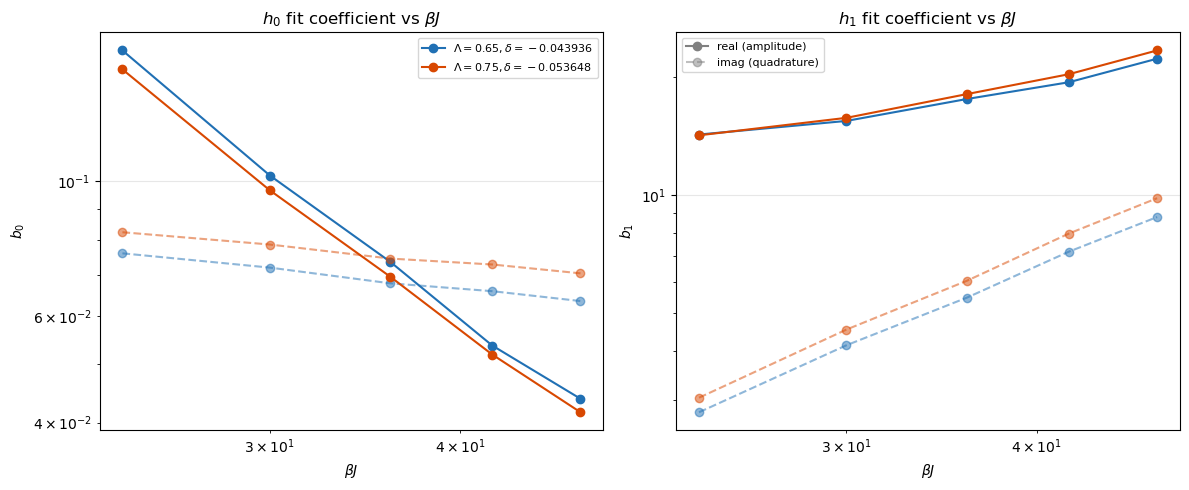

In [231]:
df_kernel_odd_full = build_kernel_odd_response(
    beta_keep=beta_keep_kernel,
    lambda_keep=lambda_keep,
    delta_keep=delta_keep,
    cutoff_keep=cutoff_keep,
    plot=False,
)

groups = sorted(
    df_kernel_odd_full[["kernel_delta", "kernel_cutoff"]]
    .drop_duplicates()
    .itertuples(index=False),
    key=lambda r: r.kernel_cutoff,
)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

for i, g in enumerate(groups):
    sub = df_kernel_odd_full[
        np.isclose(df_kernel_odd_full["kernel_delta"], g.kernel_delta)
        & np.isclose(df_kernel_odd_full["kernel_cutoff"], g.kernel_cutoff)
    ].sort_values("betaJ")

    colour = plt.colormaps[_LAMBDA_CMAPS[i % len(_LAMBDA_CMAPS)]](0.75)
    label = rf"$\Lambda={g.kernel_cutoff:g}, \delta={g.kernel_delta:g}$"

    ax0.plot(sub["betaJ"], sub["h0_amplitude"], "o-", color=colour, label=label)
    ax0.plot(sub["betaJ"], sub["h0_quadrature"], "o--", color=colour, alpha=0.5)

    ax1.plot(sub["betaJ"], sub["h1_amplitude"], "o-", color=colour, label=label)
    ax1.plot(sub["betaJ"], sub["h1_quadrature"], "o--", color=colour, alpha=0.5)

ax0.set_xlabel(r"$\beta J$")
ax1.set_xlabel(r"$\beta J$")
ax0.set_ylabel(r"$b_0$")
ax1.set_ylabel(r"$b_1$")
ax0.set_title(r"$h_0$ fit coefficient vs $\beta J$")
ax1.set_title(r"$h_1$ fit coefficient vs $\beta J$")
ax0.grid(alpha=0.3)
ax1.grid(alpha=0.3)

style_handles = [
    Line2D([0], [0], color="grey", lw=1.5, ls="-", marker="o", label="real (amplitude)"),
    Line2D([0], [0], color="grey", lw=1.5, ls="--", alpha=0.5, marker="o", label="imag (quadrature)"),
]
ax0.legend(fontsize=8, loc="best")
ax0.set_yscale("log")
ax0.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.legend(handles=style_handles, fontsize=8, loc="best")
fig.tight_layout()
plt.show()

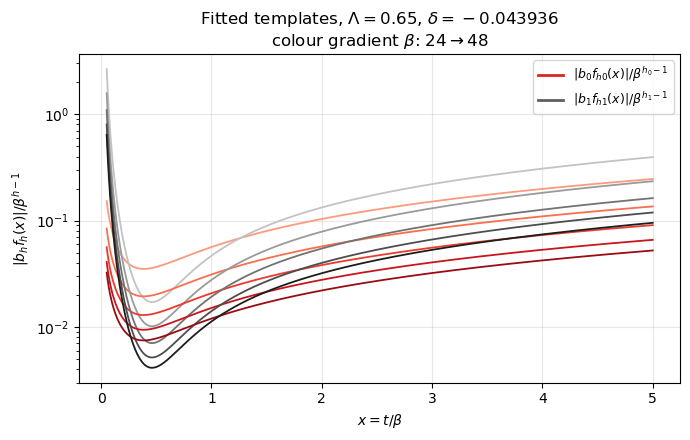

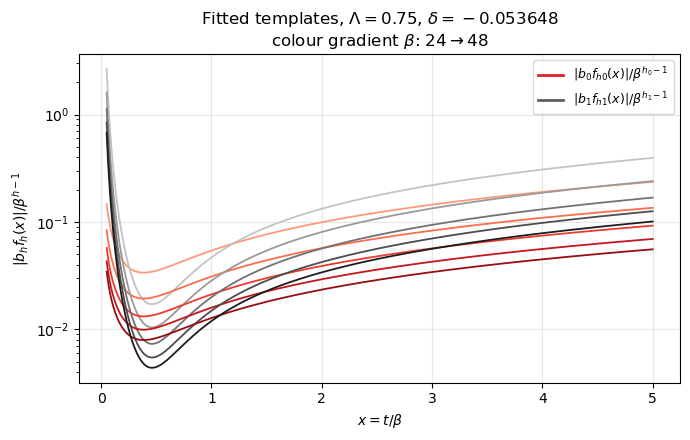

In [232]:
H0 = 2.0
x_template = np.linspace(0.05, 5.0, 500)

for g in groups:
    sub = df_kernel_odd_full[
        np.isclose(df_kernel_odd_full["kernel_delta"], g.kernel_delta)
        & np.isclose(df_kernel_odd_full["kernel_cutoff"], g.kernel_cutoff)
    ].sort_values("beta").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    cmap_h0 = plt.colormaps["Reds"]
    cmap_h1 = plt.colormaps["Greys"]

    for i, row in sub.iterrows():
        shade = 0.35 + 0.55 * i / max(len(sub) - 1, 1)
        beta = row["beta"]
        b0 = row["h0_amplitude"] + 1j * row["h0_quadrature"]
        b1 = row["h1_amplitude"] + 1j * row["h1_quadrature"]

        ax.plot(
            x_template, np.abs(b0 * f_h0(x_template)) / beta ** (H0 - 1),
            lw=1.3, color=cmap_h0(shade),
        )
        ax.plot(
            x_template, np.abs(b1 * f_h1(x_template)) / beta ** (H1 - 1),
            lw=1.3, color=cmap_h1(shade),
        )

    handles = [
        Line2D([0], [0], color=cmap_h0(0.7), lw=2, label=r"$|b_0f_{h0}(x)|/\beta^{h_0-1}$"),
        Line2D([0], [0], color=cmap_h1(0.7), lw=2, label=r"$|b_1f_{h1}(x)|/\beta^{h_1-1}$"),
    ]

    ax.set_xlabel(r"$x=t/\beta$")
    ax.set_ylabel(r"$|b_hf_h(x)|/\beta^{h-1}$")
    ax.set_title(
        rf"Fitted templates, $\Lambda={g.kernel_cutoff:g}$, $\delta={g.kernel_delta:g}$"
        "\n" + r"colour gradient $\beta$: " + f"{sub['beta'].min():g}" + r"$\to$" + f"{sub['beta'].max():g}"
    )
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    ax.legend(handles=handles, fontsize=9)
    fig.tight_layout()
    plt.show()


## 5. Euclidean templates $f_0(u)$, $f_1(u)$, $f_{00}(u)$

$f_0$ and $f_1$ recomputed here in Euclidean time $u=\tau/\beta$ (same closed form / conformal
block used for `f_h0`, `f_h1` above, just evaluated at real $u$ instead of continued to
real time via $u=-ix$). $f_{00}(u)$ has no closed form -- it comes from a four-point function --
so it is loaded from the cached table produced by `syk_matsubara_f00.ipynb` /
`syk_matsubara_kernel.ipynb`, not recomputed here.

betaJ=30 refit (u>=0.15): A=5.4944  B=9.6247  C=6.6013  (relative RMS=0.72%)


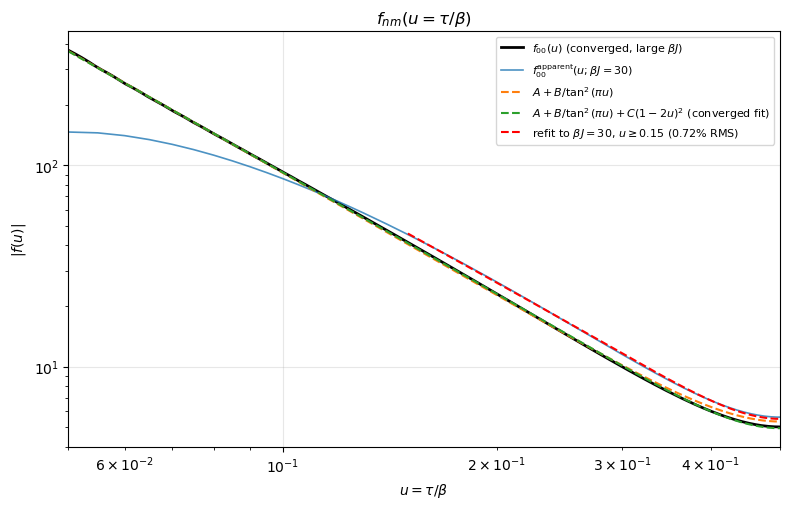

In [233]:
def f0_euclidean(u):
    u = np.asarray(u, dtype=float)
    return 2.0 + np.pi * (1.0 - 2.0 * u) / np.tan(np.pi * u)


_f1_euclid_u_grid = np.linspace(0.05, 0.5, 200)
_f1_euclid_table = np.array(
    [_general_f_h_complex(uu, H1).real for uu in _f1_euclid_u_grid]
)


def f1_euclidean(u):
    return np.interp(np.asarray(u, dtype=float), _f1_euclid_u_grid, _f1_euclid_table)


_f00_path = Path("/Users/meabh/Downloads/matsubara_tangent_output/syk_equilibrium_f00_f1_tables.npz")
if not _f00_path.exists():
    raise FileNotFoundError(
        f"{_f00_path} not found. Run syk_matsubara_f00.ipynb (in the Matsubara-kernel "
        "project) first -- it numerically extracts f00(u) and saves this table."
    )
_f00_data = np.load(_f00_path)
_f00_u_grid = _f00_data["u"]
_f00_table = _f00_data["f00"]


def f00_numeric(u):
    return np.interp(np.asarray(u, dtype=float), _f00_u_grid, _f00_table)


u_plot = np.linspace(_f00_u_grid.min(),0.5, 400) # 

# small-betaJ apparent f00(u), computed directly from the Matsubara equilibrium solver at
# betaJ=15,20,25,30 (matching this notebook's own beta_keep_eq/kernel range) -- same
# f00_apparent(u;betaJ) construction as syk_matsubara_f00.ipynb, just at small betaJ instead
# of the large-betaJ (up to 950) sweep used for the converged f00_numeric table above.
_small_betaJ_path = Path("/Users/meabh/Downloads/matsubara_tangent_output/syk_f00_apparent_small_betaJ.npz")
if not _small_betaJ_path.exists():
    raise FileNotFoundError(f"{_small_betaJ_path} not found.")
_small_betaJ_data = np.load(_small_betaJ_path)
_small_betaJ_u = _small_betaJ_data["u"]

# Refit A,B,C of the SAME ansatz directly against f00_apparent(u; betaJ=30), u in [0.05,0.5] --
# not the converged f00(u) table. Condition number is fine (~54, well-conditioned), but the
# fit quality is genuinely worse (~13% RMS) than the converged fit (~1%): the empirical
# local log-log slope of this curve only approaches the double-pole value -2 once u gtrsim 0.14
# (tau*J = u*betaJ gtrsim 4.2) -- below that, tau*J is not >> 1 at betaJ=30, so the CPT
# expansion's own validity condition is breaking down, not just the ansatz's parameters
# being off. That's the likely reason a clean 3-parameter power-law refit only partially works.
# Restricted to u >= 0.15 (tau*J = u*betaJ >= 4.5 at betaJ=30) -- excludes the u<0.15
# crossover region where tau*J is not >> 1 yet and the double-pole ansatz genuinely doesn't
# apply (confirmed separately: the empirical local log-log slope of this curve only reaches
# the double-pole value -2 once u gtrsim 0.14). Fit quality is dramatically better once that
# region is excluded (0.72% RMS here vs. 13.27% fitting all the way down to u=0.05).
_fit_mask = (_small_betaJ_u >= 0.15) & (_small_betaJ_u <= 0.5)
_uf = _small_betaJ_u[_fit_mask]
_target30 = _small_betaJ_data["betaJ_30"][_fit_mask]
_cot2 = 1.0 / np.tan(np.pi * _uf) ** 2
_v2 = (1 - 2 * _uf) ** 2
_basis30 = np.column_stack([_cot2, _v2, np.ones_like(_uf)])
_coef30, *_ = np.linalg.lstsq(_basis30, _target30, rcond=None)
B_30, C_30, A_30 = _coef30
_rel_rms_30 = np.sqrt(np.mean((_target30 - _basis30 @ _coef30) ** 2)) / np.sqrt(np.mean(_target30**2))
print(f"betaJ=30 refit (u>=0.15): A={A_30:.4f}  B={B_30:.4f}  C={C_30:.4f}  (relative RMS={_rel_rms_30:.2%})")

fig, ax = plt.subplots(figsize=(8, 5.2))
ax.plot(u_plot, np.abs(f00_numeric(u_plot)), lw=2, color="black", label=r"$f_{00}(u)$ (converged, large $\beta J$)")
for _b in [30]:
    ax.plot(_small_betaJ_u, np.abs(_small_betaJ_data[f"betaJ_{_b}"]), lw=1.2, alpha=0.8,
            label=rf"$f_{{00}}^{{\rm apparent}}(u;\beta J={_b})$")
ax.plot(u_plot, np.abs(((9.14))/(np.tan(np.pi*u_plot))**2+5.33), ls='--', label=r"$A +B/\tan^2(\pi u)$")
ax.plot(u_plot, np.abs(((9.076))/(np.tan(np.pi*u_plot))**2+4.937+2.322*(1-2*u_plot)**2), ls='--', label=r"$A +B/\tan^2(\pi u) +C (1-2u)^2$ (converged fit)")
_u_plot_refit = np.linspace(0.15, 0.5, 200)
ax.plot(_u_plot_refit, np.abs(B_30/(np.tan(np.pi*_u_plot_refit))**2 + A_30 + C_30*(1-2*_u_plot_refit)**2), ls='--', color="red",
        label=rf"refit to $\beta J=30$, $u\geq0.15$ ({_rel_rms_30:.2%} RMS)")
ax.set_xlabel(r"$u=\tau/\beta$")
ax.set_ylabel(r"$|f(u)|$")
ax.set_title(r"$f_{nm}(u=\tau/\beta)$")
ax.set_xlim((0.05,0.5))
ax.set_yscale("log")
ax.set_xscale("log")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [234]:
np.abs((np.pi*(1-2/2))/np.tan(np.pi/2)+2), np.abs(f00_numeric(1/2)), np.abs(f1_euclidean(1/2))

(2.0, 5.010684461142549, 4.737328751142825)

In [114]:
np.abs((4.756/np.sin(np.pi/2)**2 + 4.652*(1-2/2)/np.tan(np.pi/2)/np.sin(np.pi/2) + 8.064*(1-2/2)**2))

4.756

### Polynomial fit over $0<\tau<\beta/4$

Restricting to $u=\tau/\beta\in(u_{\min},0.25]$ (where $u_{\min}$ is the cached $f_{00}$ table's
lower edge, 0.05) and least-squares fitting each of $f_0,f_1,f_{00}$ by a plain degree-$N$
polynomial in $u$ over that sub-range, overlaid as dashed curves. This is well inside where all
three functions are monotonically falling (away from the $u\to0,1$ divergence and past $u=0.5$'s
turnaround), so a modest-degree polynomial should track them closely -- the fit RMS printed below
is the check on that.

$f_0(u)$
  free fit:   a = 0.87221834, p = -1.04599818, log-RMS = 3.545e-03
  fixed fit:  a = 0.9699045, p = -1.00000000, log-RMS = 1.535e-02

$f_1(u)$ ($h_1\approx3.7735$)
  free fit:   a = 0.80154541, p = -2.84997086, log-RMS = 6.965e-03
  fixed fit:  a = 0.95617817, p = -2.77353562, log-RMS = 2.578e-02

$f_{00}(u)$
  free fit:   a = 0.95322633, p = -1.98815452, log-RMS = 4.263e-03
  fixed fit:  a = 0.92752016, p = -2.00000000, log-RMS = 5.741e-03



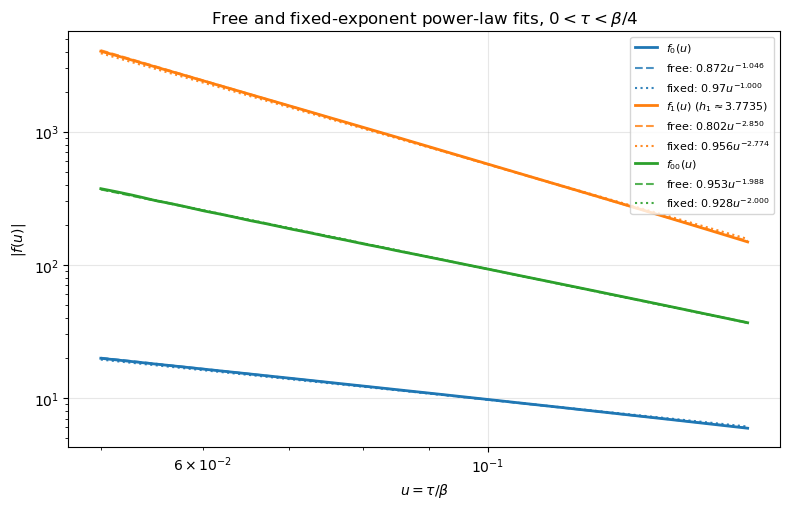

In [116]:
u_min_fit = max(_f00_u_grid.min(), 1e-6)
u_max_fit = 1/2/np.pi
u_fit = np.linspace(u_min_fit, u_max_fit, 300)

fig, ax = plt.subplots(figsize=(8, 5.2))

datasets = [
    (r"$f_0(u)$", f0_euclidean, "tab:blue",   -H0 + 1),
    (rf"$f_1(u)$ ($h_1\approx{H1:.4f}$)",
     f1_euclidean, "tab:orange", -H1 + 1),
    (r"$f_{00}(u)$", f00_numeric, "tab:green", -2 * H0 + 2),
]

for label, func, color, p_theory in datasets:
    y = func(u_fit)
    y_abs = np.abs(y)

    # Valid points for log-log fitting
    mask = (
        np.isfinite(u_fit)
        & np.isfinite(y_abs)
        & (u_fit > 0)
        & (y_abs > 0)
    )

    u_valid = u_fit[mask]
    y_valid = y_abs[mask]

    # ------------------------------------------------------------
    # 1. FREE POWER-LAW FIT: y = a_free * u^p_free
    # ------------------------------------------------------------
    p_free, log_a_free = np.polyfit(
        np.log(u_valid),
        np.log(y_valid),
        1,
    )
    a_free = np.exp(log_a_free)

    y_free = a_free * u_fit**p_free

    # ------------------------------------------------------------
    # 2. FIXED-EXPONENT FIT: y = a_theory * u^p_theory
    #
    # Fit only log(a):
    # log(y) = log(a) + p_theory * log(u)
    # ------------------------------------------------------------
    log_a_theory = np.mean(
        np.log(y_valid) - p_theory * np.log(u_valid)
    )
    a_theory = np.exp(log_a_theory)

    y_theory = a_theory * u_fit**p_theory

    # ------------------------------------------------------------
    # Errors in log space
    # ------------------------------------------------------------
    log_rms_free = np.sqrt(
        np.mean(
            (
                np.log(y_valid)
                - np.log(a_free * u_valid**p_free)
            )**2
        )
    )

    log_rms_theory = np.sqrt(
        np.mean(
            (
                np.log(y_valid)
                - np.log(a_theory * u_valid**p_theory)
            )**2
        )
    )

    print(label)
    print(
        f"  free fit:   a = {a_free:.8g}, "
        f"p = {p_free:.8f}, "
        f"log-RMS = {log_rms_free:.3e}"
    )
    print(
        f"  fixed fit:  a = {a_theory:.8g}, "
        f"p = {p_theory:.8f}, "
        f"log-RMS = {log_rms_theory:.3e}"
    )
    print()

    # Data
    ax.plot(
        u_fit,
        y_abs,
        lw=2,
        color=color,
        label=label,
    )

    # Free exponent fit
    ax.plot(
        u_fit,
        y_free,
        lw=1.5,
        ls="--",
        color=color,
        alpha=0.8,
        label=rf"free: ${a_free:.3g}u^{{{p_free:.3f}}}$",
    )

    # Theory-fixed exponent fit
    ax.plot(
        u_fit,
        y_theory,
        lw=1.5,
        ls=":",
        color=color,
        alpha=0.9,
        label=rf"fixed: ${a_theory:.3g}u^{{{p_theory:.3f}}}$",
    )

ax.set_xlabel(r"$u=\tau/\beta$")
ax.set_ylabel(r"$|f(u)|$")
ax.set_title(
    r"Free and fixed-exponent power-law fits, $0<\tau<\beta/4$"
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.grid(alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()